# Product Analysis, Activation Gap Diagnosis, and Modeling Base Preparation

---

## Project Overview

### Objective

This project represents **Part 1** of the analytical workflow for the Interactive **Data Analysis in R Course** on **Stepik**.

The main objective of this phase is to analyze user behavior at both the user and step levels, identify where learners disengage, and translate these findings into data-driven recommendations for improving retention and course completion.

This part establishes the analytical foundation for the next stages of the project. It identifies the main product problem as an early **Activation Gap**: many users disengage before moving from passive content consumption into meaningful practical engagement.

In addition to the product diagnosis, this phase prepares the downstream modeling base by applying a conservative P99-based filtering strategy, excluding unresolved `is_in_progress` users from the final analytical sample, constructing user-level behavioral features, and exporting processed datasets for:

- [**Part 2: Behavioral Segmentation and Completion Outcome Analysis**](02_behavioral_segmentation.ipynb)
- [**Part 3: Early Completion Risk Modeling**](03_completion_risk_modeling.ipynb)

---

### Project Context

This analytical workflow is organized into three connected stages.

**Part 1: Product Analysis, EDA, and Activation Gap Diagnosis**  
This phase analyzes raw event and submission logs to understand how users move through the course, where they disengage, and whether dropout is mainly driven by early onboarding friction, assignment difficulty, or localized step-level bottlenecks.

[**Part 2: Behavioral Segmentation and Completion Outcome Analysis**](02_behavioral_segmentation.ipynb)  
The second phase uses the resolved user-level analytical sample created in **Part 1** to identify behaviorally distinct learner groups through unsupervised learning. These segments help summarize different learner trajectories and examine how engagement patterns are associated with completion outcomes.

[**Part 3: Early Completion Risk Modeling**](03_completion_risk_modeling.ipynb) 
The final phase uses early 10-day behavioral signals to estimate users' likelihood of eventual course completion and rank users by non-completion risk for proactive retention prioritization.

Therefore, **Part 1** has two roles: it diagnoses the main product problem and creates the cleaned analytical foundation used in the later segmentation and prediction workflows.

---

### Data Description

The analysis is based on two raw Stepik datasets covering the period between **mid-2015 and mid-2018**.

**Course context**

- **198 total steps**, including **76 practical assignments**
- **Maximum score:** 88 points
- **Completion threshold:** 75 points
- **Honor-level performance:** 85+ points
- **Flexible progression:** users can navigate non-linearly, and progress is measured through cumulative points rather than a strictly linear sequence

**1. `event_data_train.csv`**

Loaded as `events_data`.

This dataset contains event-level records of user interactions.

Main variables:

- `step_id` — anonymized step identifier
- `user_id` — anonymized user identifier
- `timestamp` — event time in Unix timestamp format
- `action` — type of user action:
  - `discovered` — user navigated to a step
  - `viewed` — user viewed the content
  - `started_attempt` — user began solving a practical task
  - `passed` — user successfully completed the step; applies to both theory and practical tasks

**2. `submissions_data_train.csv`**

Loaded as `submissions_data`.

This dataset contains submission-level records for practical assignments.

Main variables:

- `step_id` — anonymized step identifier
- `user_id` — anonymized user identifier
- `timestamp` — submission time in Unix timestamp format
- `submission_status` — submission result: `correct` or `wrong`

---

### Analytical Framing

The analysis focuses on the transition from passive course exposure to meaningful practical engagement.

A key distinction is made between users who:

- only discover or view course material,
- start practical assignments,
- submit solutions,
- achieve correct submissions,
- accumulate enough points to complete the course.

This framing is important because user loss can happen at different behavioral stages. The main analytical question is whether dropout is primarily caused by assignment difficulty after users begin solving tasks, or whether the larger product problem occurs earlier, before practical activation.

The analysis shows that the largest observed loss happens before users submit their first solution. This early disengagement is summarized as the **Activation Gap**.

---

### Methodological Strategy

The workflow follows a structured product analytics process.

1. **Data loading and validation**
   - Load raw event and submission logs.
   - Validate column structure, timestamp logic, event types, and user-level consistency.
   - Convert Unix timestamps into interpretable datetime fields.
   - Remove a small number of fully duplicated records.

2. **Course and event structure analysis**
   - Review event types and step-level interaction patterns.
   - Distinguish general course activity from practical-assignment behavior.
   - Validate the relationship between `started_attempt`, submissions, correct submissions, and passed events.
   - Reconstruct approximate course order where needed.

3. **User engagement and churn funnel analysis**
   - Analyze how users move from discovery and viewing into attempts and submissions.
   - Identify pre-submission churn groups:
     - Theorists,
     - Task Viewers,
     - Unfinished Attempts.
   - Compare pre-submission churn with post-submission outcomes.

4. **User-level activity diagnostics**
   - Aggregate user-level engagement, activity, submission, and progress metrics.
   - Compare mean- and median-based diagnostics under strong right-skewness.
   - Identify whether low engagement is a structural majority pattern or an artifact of extreme users.

5. **P99-based outlier diagnostics**
   - Identify extreme high-activity users using the 99th percentile of key engagement metrics.
   - Compare full-sample and P99-filtered results.
   - Use the full dataset for descriptive product context.
   - Use the P99-filtered sample for robustness checks and downstream modeling preparation.

6. **Step-level friction analysis**
   - Analyze step-level traffic, starts, pass rates, submissions, and final observed steps.
   - Reconstruct course sequence for step-level flow analysis.
   - Identify localized friction using traffic drops, final-exit concentration, low pass rates, and high submission effort.
   - Compare lower- and higher-weight practical assignments as an approximate difficulty proxy.

7. **Resolved modeling base preparation**
   - Define the downstream analytical sample `model_base`.
   - Exclude P99-defined extreme users.
   - Exclude unresolved non-completed users still marked as `is_in_progress`.
   - Construct user-level behavioral features for segmentation and prediction.

8. **Data export for downstream stages**
   - Export processed clustering features for [**Part 2: Behavioral Segmentation and Completion Outcome Analysis**](02_behavioral_segmentation.ipynb).
   - Export early 10-day behavioral features and completion labels for [**Part 3: Early Completion Risk Modeling**](03_completion_risk_modeling.ipynb).
   - Keep feature tables and target tables separate to reduce leakage risk and support reproducibility.

---

### Key Analytical Questions

This project addresses five main questions:

1. **Where does the largest user drop-off occur in the course journey?**

2. **Do users mainly disengage before practical activation, during attempts, or after submitting solutions?**

3. **Is course friction driven by a few localized bottleneck steps or by a broader structural issue?**

4. **Do higher-weight practical assignments show stronger friction signals than lower-weight assignments?**

5. **How should the cleaned and resolved analytical sample be prepared for downstream clustering and prediction?**

---

### Key Findings

The analysis identifies several core findings.

**User activity is strongly right-skewed.**  
A small group of P99-defined high-activity users inflates average-based metrics, while median values remain much more stable and better represent typical learner behavior.

**The main product problem is early activation.**  
A large share of users disengage before submitting a solution. This indicates that the largest barrier occurs before meaningful practical engagement.

**Pre-submission churn is substantial.**  
Nearly half of all users never submit a solution. This early loss includes users who never reach assignments, users who view assignments but do not start them, and users who start but never submit.

**Task difficulty is not the main initial barrier.**  
Once users reach active problem-solving, outcomes are generally strong. Most users who submit at least once eventually achieve at least one correct submission.

**Early drop-off is concentrated near the beginning of the course.**  
Step-level analysis shows that many final observed interactions happen in the early part of the course, especially around the first reconstructed steps.

**Friction is localized rather than fully systemic.**  
Cross-metric step-level diagnostics identify only a limited number of high-priority steps with overlapping risk signals.

**Difficulty matters later, but affects fewer users.**  
Higher-weight assignments show stronger friction signals, but most disengagement happens before users reach these later, more difficult tasks.

---

### Expected Business Use

The findings from this phase support product and retention strategy design.

The main recommendation is to reduce the **Activation Gap** by helping users move from passive viewing into practical engagement earlier. Potential actions include clearer onboarding, first-task guidance, progress prompts, simplified first assignment entry, skeleton-code support, and better navigation toward practical exercises.

This part also creates the analytical foundation for the next stages:

- [**Part 2: Behavioral Segmentation and Completion Outcome Analysis**](02_behavioral_segmentation.ipynb) uses the cleaned `cluster_features_model_base` sample to identify learner segments.
- [**Part 3: Early Completion Risk Modeling**](03_completion_risk_modeling.ipynb) uses `prediction_features_10d_model_base` to model completion likelihood and rank users by non-completion risk.

The results should be interpreted as product diagnostics and modeling preparation, not as causal evidence of intervention effectiveness. Future A/B testing would be required to evaluate whether specific interventions improve retention and completion outcomes.

---

### Assumptions & Limitations

**Assumptions**

- Event logs accurately reflect user behavior.
- `started_attempt` is a valid proxy for practical-task activation.
- Assignment-level passed events in `events_data` are used for practical-progress event counts, while correct submissions in `submissions_data` are used for score accumulation and submission-outcome features.
- The reconstructed course order provides a reasonable approximation of the learner journey.
- Assignment score weights can be used as an approximate difficulty proxy.
- The 14-day inactivity rule is a practical way to identify unresolved `is_in_progress` users at the dataset snapshot.

**Limitations**

- The analysis is based on a historical snapshot and may not reflect the current course structure or current learner behavior.
- Users can navigate non-linearly, so reconstructed step order and step-to-step traffic ratios should be interpreted as approximations rather than exact individual paths.
- Some minor logging inconsistencies exist, such as rare cases with missing view/discovery events or correct submissions without matching passed events.
- Assignment score weights were reconstructed manually rather than obtained directly from raw platform metadata, so score-based difficulty analyses should be interpreted as approximate.
- P99-defined extreme high-activity users are excluded from the downstream modeling sample, so later segmentation and prediction results may underrepresent very high-intensity usage behavior.
- Users still marked as `is_in_progress` are excluded from the downstream analytical sample to reduce right-censoring, but this also means that the modeling sample focuses on resolved learner trajectories.
- The findings are descriptive and diagnostic. They do not establish causal effects of specific interventions.

---

In [1]:
# Environment Setup
suppressPackageStartupMessages({
  library(lubridate)
  library(dplyr)
  library(data.table)
  library(ggplot2)
})

---

## Data Loading & Exploration

In [2]:
# Project paths
project_root <- here::here()

data_dir <- file.path(project_root, "data")
raw_data_dir <- file.path(data_dir, "raw")
processed_data_dir <- file.path(data_dir, "processed")

dir.create(raw_data_dir, recursive = TRUE, showWarnings = FALSE)
dir.create(processed_data_dir, recursive = TRUE, showWarnings = FALSE)

In [3]:
# Public Stepik datasets
urls <- c(
  "https://stepik.org/media/attachments/course/4852/event_data_train.zip",
  "https://stepik.org/media/attachments/course/4852/submissions_data_train.zip"
)

# Download and extract archives
for (url in urls) {
  file_name <- basename(url)
  dest_path <- file.path(raw_data_dir, file_name)
  extracted_file <- file.path(
    raw_data_dir,
    sub("\\.zip$", ".csv", file_name)
  )

  if (!file.exists(dest_path)) {
    message("Downloading ", file_name, "...")
    download.file(
      url = url,
      destfile = dest_path,
      mode = "wb"
    )
  }

  if (!file.exists(extracted_file)) {
    message("Extracting ", file_name, "...")
    unzip(
      zipfile = dest_path,
      exdir = raw_data_dir
    )
  }
}

In [4]:
# Validate required files
required_files <- c(
  file.path(raw_data_dir, "event_data_train.csv"),
  file.path(raw_data_dir, "submissions_data_train.csv")
)

missing_files <- required_files[!file.exists(required_files)]

if (length(missing_files) > 0) {
  stop(
    "Required data files were not created:\n",
    paste(missing_files, collapse = "\n")
  )
}

In [5]:
# Using data.table::fread for high-performance data loading
events_data <- fread(file.path(raw_data_dir, "event_data_train.csv"))
submissions_data <- fread(file.path(raw_data_dir, "submissions_data_train.csv"))

In [6]:
# Display memory usage for the events and submissions datasets in MB
cat("events_data size:", sub("Mb", "MB", format(object.size(events_data), units = "MB")), "\n")
cat("submissions_data size:", sub("Mb", "MB", format(object.size(submissions_data), units = "MB")), "\n")

events_data size: 66.4 MB 
submissions_data size: 9.7 MB 


In [7]:
# Verify dataset dimensions 
# Expected: 3,480,703 rows and 4 columns
dim(events_data)

# Expected: 509,104 rows and 4 columns
dim(submissions_data)

[1] 3480703       4

[1] 509104      4

In [8]:
# Convert Unix timestamps to human-readable datetime objects
events_data[, timestamp_dt := as_datetime(timestamp)]
submissions_data[, timestamp_dt := as_datetime(timestamp)]

---

### Global Overview: events_data

In [9]:
# Set seed for reproducibility so the same sample is shown every time
set.seed(42)
events_data %>% slice_sample(n = 10)

step_id,timestamp,action,user_id,timestamp_dt
<int>,<int>,<chr>,<int>,<dttm>
33537,1521482689,viewed,17861,2018-03-19 18:04:49
32815,1434476991,passed,20433,2015-06-16 17:49:51
34041,1437333455,discovered,1770,2015-07-19 19:17:35
32188,1462200591,viewed,13017,2016-05-02 14:49:51
31971,1521275410,viewed,15979,2018-03-17 08:30:10
32191,1519046685,viewed,24699,2018-02-19 13:24:45
31981,1436182347,started_attempt,14912,2015-07-06 11:32:27
33684,1479889628,discovered,1948,2016-11-23 08:27:08
33439,1516541346,passed,25659,2018-01-21 13:29:06


In [10]:
# Inspect dataset structure and variable types 
glimpse(events_data)

Rows: 3,480,703
Columns: 5
$ step_id      <int> 32815, 32815, 32815, 32811, 32811, 32811, 32929, 32929, 3…
$ timestamp    <int> 1434340848, 1434340848, 1434340848, 1434340895, 143434089…
$ action       <chr> "viewed", "passed", "discovered", "discovered", "viewed",…
$ user_id      <int> 17632, 17632, 17632, 17632, 17632, 17632, 17632, 17632, 1…
$ timestamp_dt <dttm> 2015-06-15 04:00:48, 2015-06-15 04:00:48, 2015-06-15 04:…


In [11]:
# Count unique values across all columns
events_data %>%
    summarise(across(everything(),n_distinct))

step_id,timestamp,action,user_id,timestamp_dt
<int>,<int>,<int>,<int>,<int>
198,2196932,4,19234,2196932


In [12]:
# Review summary statistics to validate ranges and overall consistency
summary(events_data)

    step_id         timestamp               action           user_id     
 Min.   : 30456   Min.   :1.434e+09   Length   :3480703   Min.   :    1  
 1st Qu.: 32179   1st Qu.:1.450e+09   N.unique :      4   1st Qu.: 6642  
 Median : 32929   Median :1.484e+09   N.blank  :      0   Median :13208  
 Mean   : 34874   Mean   :1.480e+09   Min.nchar:      6   Mean   :13315  
 3rd Qu.: 33481   3rd Qu.:1.508e+09   Max.nchar:     15   3rd Qu.:20144  
 Max.   :158433   Max.   :1.527e+09                       Max.   :26798  
  timestamp_dt                
 Min.   :2015-06-15 04:00:48  
 1st Qu.:2015-12-16 12:57:45  
 Median :2017-01-08 19:25:52  
 Mean   :2016-11-27 23:09:31  
 3rd Qu.:2017-10-13 10:08:22  
 Max.   :2018-05-19 23:33:31  

> **Technical Note on Step IDs**
> 
> The unusually high `step_id` values are expected. Step IDs are assigned across the entire platform, not relative to this specific course. Since new steps are continuously added, IDs may appear non-sequential or large. This is **expected behavior** and **does not affect the statistical integrity** of the analysis.

In [13]:
# Inspect unique values of the action variable to verify all event types
unique(events_data$action)

[1] "viewed"          "passed"          "discovered"      "started_attempt"

In [14]:
# Calculate the count and percentage of each action
events_data %>% count(action) %>% mutate(p = n / sum(n))

action,n,p
<chr>,<int>,<dbl>
discovered,689495,0.19809073
passed,650331,0.18683898
started_attempt,310047,0.08907597
viewed,1830830,0.52599432


In [15]:
# Count missing values (NAs) in each column
colSums(is.na(events_data))

step_id    timestamp       action      user_id timestamp_dt 
           0            0            0            0            0

---

### Global Overview: submissions_data

In [16]:
# Set seed for reproducibility so the same sample is shown every time
set.seed(42)
submissions_data %>% slice_sample(n = 10)

step_id,timestamp,submission_status,user_id,timestamp_dt
<int>,<int>,<chr>,<int>,<dttm>
33540,1436127280,wrong,13598,2015-07-05 20:14:40
32244,1435074860,wrong,8405,2015-06-23 15:54:20
32198,1436107240,wrong,7775,2015-07-05 14:40:40
33480,1436206424,correct,73,2015-07-06 18:13:44
32810,1435086106,wrong,21735,2015-06-23 19:01:46
31978,1518888119,wrong,11073,2018-02-17 17:21:59
32198,1514229606,wrong,14090,2017-12-25 19:20:06
33540,1436089851,correct,15743,2015-07-05 09:50:51
32809,1498678904,wrong,23034,2017-06-28 19:41:44


In [17]:
# Inspect dataset structure and variable types 
glimpse(submissions_data)

Rows: 509,104
Columns: 5
$ step_id           <int> 31971, 31972, 31972, 31972, 31976, 31976, 31976, 319…
$ timestamp         <int> 1434349275, 1434348300, 1478852149, 1478852164, 1434…
$ submission_status <chr> "correct", "correct", "wrong", "correct", "wrong", "…
$ user_id           <int> 15853, 15853, 15853, 15853, 15853, 15853, 15853, 158…
$ timestamp_dt      <dttm> 2015-06-15 06:21:15, 2015-06-15 06:05:00, 2016-11-1…


In [18]:
# Count unique values across all columns
submissions_data %>%
    summarise(across(everything(), n_distinct))

step_id,timestamp,submission_status,user_id,timestamp_dt
<int>,<int>,<int>,<int>,<int>
76,504343,2,9940,504343


In [19]:
# Review summary statistics to validate ranges and overall consistency
summary(submissions_data)

    step_id         timestamp         submission_status     user_id     
 Min.   : 31971   Min.   :1.434e+09   Length   :509104   Min.   :    2  
 1st Qu.: 32031   1st Qu.:1.450e+09   N.unique :     2   1st Qu.: 6431  
 Median : 32763   Median :1.484e+09   N.blank  :     0   Median :13082  
 Mean   : 33733   Mean   :1.481e+09   Min.nchar:     5   Mean   :13199  
 3rd Qu.: 33481   3rd Qu.:1.508e+09   Max.nchar:     7   3rd Qu.:19985  
 Max.   :120745   Max.   :1.527e+09                      Max.   :26798  
  timestamp_dt                
 Min.   :2015-06-15 04:02:24  
 1st Qu.:2015-12-12 19:59:30  
 Median :2017-01-13 20:16:27  
 Mean   :2016-12-01 08:53:27  
 3rd Qu.:2017-10-18 11:32:05  
 Max.   :2018-05-19 23:07:07  

> **Note on Step IDs**
>
> Step IDs correspond to steps in `events_data`. As with `events_data`, IDs are assigned platform-wide and may be non-sequential or large. This is **expected** and does **not affect** the analysis.

In [20]:
# Inspect unique values of the submission status variable to verify all status types
unique(submissions_data$submission_status)

[1] "correct" "wrong"

In [21]:
# Calculate the count and proportion (percentage) of each submission_status
submissions_data %>% count(submission_status) %>% mutate(p = n / sum(n))

submission_status,n,p
<chr>,<int>,<dbl>
correct,222705,0.437445
wrong,286399,0.562555


In [22]:
# Count missing values (NAs) in each column
colSums(is.na(submissions_data))

step_id         timestamp submission_status           user_id 
                0                 0                 0                 0 
     timestamp_dt 
                0

---

### Deduplication: Both Datasets

In [23]:
# Using sprintf to correctly format proportions as percentages
event_dup_prop <- sum(duplicated(events_data)) / nrow(events_data)
sub_dup_prop   <- sum(duplicated(submissions_data)) / nrow(submissions_data)

cat("Events Duplicates:", sprintf("%.3f%%", event_dup_prop * 100), "\n")
cat("Submissions Duplicates:", sprintf("%.3f%%", sub_dup_prop * 100), "\n")

Events Duplicates: 0.067% 
Submissions Duplicates: 0.021% 


> **Technical Note: Duplicate Records**
>
> A small number of fully duplicated rows was identified:
>
> * **0.067%** in `events_data`  
> * **0.021%** in `submissions_data` 
>
> These duplicates were removed during preprocessing to ensure data integrity and avoid minor inflation of activity-based metrics.
>
> Given their negligible share (**<0.1%**), their removal does not affect overall distributions or analytical conclusions and is treated as a standard data-cleaning step.

In [24]:
# Remove duplicate rows to ensure data uniqueness
events_data <- events_data[!duplicated(events_data),]
submissions_data <- submissions_data[!duplicated(submissions_data),]

---

## Data Understanding 

### Checking Actions Consistency

In [25]:
# Check the number of unique steps for each action type
cat("Number of steps discovered:", length(unique(events_data[action == "discovered", step_id])), "\n")
cat("Number of steps viewed:", length(unique(events_data[action == "viewed", step_id])), "\n")
cat("Number of practical steps started (started_attempt):", length(unique(events_data[action == "started_attempt", step_id])), "\n")
cat("Number of steps passed:", length(unique(events_data[action == "passed", step_id])), "\n")

Number of steps discovered: 198 
Number of steps viewed: 198 
Number of practical steps started (started_attempt): 76 
Number of steps passed: 198 


In [26]:
# Define the canonical set of assignment steps from submission data
assignment_step_ids <- unique(submissions_data$step_id)

# Extract the assignment-step set identified through started_attempt events
started_attempt_step_ids <- unique(
  events_data[action == "started_attempt", step_id]
)

# Verify that both sources identify exactly the same assignment steps
stopifnot(
  setequal(
    assignment_step_ids,
    started_attempt_step_ids
  )
)

In [27]:
# Flag assignment steps in the event-level dataset
events_data[
  ,
  is_assignment := step_id %in% assignment_step_ids
]

In [28]:
# Check the number of unique steps for each submission status
cat("Number of steps with submission status 'wrong':", length(unique(submissions_data[submission_status == "wrong", step_id])), "\n")
cat("Number of steps with submission status 'correct':", length(unique(submissions_data[submission_status == "correct", step_id])), "\n")

Number of steps with submission status 'wrong': 76 
Number of steps with submission status 'correct': 76 


---

### Consistency check: 'passed'(events_data) and 'correct'(submissions_data)

In [29]:
# Step-level consistency check:
# all steps with correct submissions are present among assignment-level passed events.
all(
  submissions_data[submission_status == "correct", unique(step_id)] %in%
    events_data[action == "passed" & is_assignment == TRUE, unique(step_id)]
)

[1] TRUE

In [30]:
# Validate consistency between successful assignment submissions
# and corresponding "passed" events in the event log.

# Keep one unique user-step pair for every assignment
# with at least one correct submission.
# Repeated correct submissions for the same user and step
# are counted only once.
correct_user_steps <- unique(
  submissions_data[
    submission_status == "correct",
    .(user_id, step_id)
  ]
)

# Keep one unique user-step pair for every practical assignment
# with a recorded "passed" event.
passed_assignment_user_steps <- unique(
  events_data[
    action == "passed" & is_assignment == TRUE,
    .(user_id, step_id)
  ]
)

In [31]:
# Identify correct user-step submission pairs for which
# no matching practical-assignment "passed" event exists.
# This is a logging-consistency check and does not exclude
# valid 0-point non-graded assignments.
missing_passed_events <- fsetdiff(
  correct_user_steps,
  passed_assignment_user_steps
)

# Display the unmatched user-step pairs for further inspection.
missing_passed_events

user_id,step_id
<int>,<int>
1046,31971
1046,31972
1046,31976
1046,31977
1046,31978
1046,31979
1046,31981
1046,31983
1046,32031


In [32]:
# Count user-step pairs with a correct submission but no matching passed event,
# and express their share relative to all correct user-step pairs.
cat(
  "Correct user-step pairs without matching passed event:",
  nrow(missing_passed_events),
  sprintf("(%.4f%%)", nrow(missing_passed_events) / nrow(correct_user_steps) * 100),
  "\n"
)

Correct user-step pairs without matching passed event: 18 (0.0083%) 


>**Submission-to-Passed Event Consistency**
>
>At the step level, all steps with correct submissions are represented among assignment-level `passed` events.  
>A stricter user-step validation identified 18 correct user-step pairs without a matching passed event. These cases are extremely rare relative to all correct user-step pairs and are concentrated among a small number of users, suggesting minor logging inconsistencies rather than systematic data failure.
>
>For scoring and completion-related features, `submissions_data` is used as the primary source of truth because it directly records `correct` / `wrong` outcomes.

---

## User Engagement & Churn Funnel Analysis

In [33]:
# Prepare base user groups
all_users <- unique(events_data$user_id)

users_with_submissions <- unique(submissions_data$user_id)

users_with_started_attempt <- unique(
  events_data[action == "started_attempt", user_id]
)

n_all_users <- length(all_users)

In [34]:
# Sanity check: all submitters are present in the base user population
stopifnot(all(users_with_submissions %in% all_users))

In [35]:
# Pre-submission churn groups

# Global Dropouts:
# users who never submitted any solution
users_non_submitters <- setdiff(all_users, users_with_submissions)
n_non_submitters <- length(users_non_submitters)

# Unfinished Attempts:
# users who started an attempt but never submitted
users_started_no_submission <- setdiff(
  users_with_started_attempt,
  users_with_submissions
)
n_started_no_submission <- length(users_started_no_submission)

# Non-Starters:
# users who never started any attempt
users_no_started_attempt <- setdiff(
  all_users,
  users_with_started_attempt
)
n_no_started_attempt <- length(users_no_started_attempt)

# Task Viewers:
# non-starters who viewed at least one assignment
# but never started an attempt
users_viewed_assignment_no_started <- unique(
  events_data[
    user_id %in% users_no_started_attempt &
      is_assignment == TRUE &
      action == "viewed",
    user_id
  ]
)
n_viewed_assignment_no_started <- length(users_viewed_assignment_no_started)

# Theorists:
# non-starters who never viewed any assignment
users_never_viewed_assignment <- setdiff(
  users_no_started_attempt,
  users_viewed_assignment_no_started
)
n_never_viewed_assignment <- length(users_never_viewed_assignment)

In [36]:
# Post-submission outcomes

# Submitters:
# users who made at least one submission
users_submitters <- users_with_submissions
n_submitters <- length(users_submitters)

# Passed users:
# users with at least one correct submission
users_with_correct <- unique(
  submissions_data[submission_status == "correct", user_id]
)
passed_users <- length(users_with_correct)

# Strugglers:
# users who submitted, but never had a correct submission
users_strugglers <- setdiff(users_submitters, users_with_correct)
strugglers <- length(users_strugglers)

In [37]:
# Convert a count to a percentage
pct <- function(x, base) {
  100 * x / base
}

# Format a funnel node label with user count and percentages
fmt_node <- function(label, n, base_all, base_parent = NULL) {
  if (is.null(base_parent)) {
    sprintf(
      "%s: %d (%.1f%% of all users)",
      label,
      n,
      pct(n, base_all)
    )
  } else {
    sprintf(
      "%s: %d (%.1f%% of all users; %.1f%% of parent)",
      label,
      n,
      pct(n, base_all),
      pct(n, base_parent)
    )
  }
}

In [38]:
# Internal consistency checks
stopifnot(
  n_started_no_submission + n_no_started_attempt == n_non_submitters,

  n_viewed_assignment_no_started +
    n_never_viewed_assignment ==
    n_no_started_attempt,

  n_never_viewed_assignment +
    n_viewed_assignment_no_started +
    n_started_no_submission ==
    n_non_submitters,

  n_submitters == passed_users + strugglers
)

In [39]:
# USER FLOW OVERVIEW
cat("\n============================================================\n")
cat("                  USER FLOW OVERVIEW\n")
cat("============================================================\n\n")

cat(sprintf("All Users: %d (100.0%%)\n", n_all_users))
cat(sprintf("├── %s\n",
            fmt_node("Reached submission phase", n_submitters, n_all_users)))
cat(sprintf("└── %s\n",
            fmt_node("Churned before first submission", n_non_submitters, n_all_users)))


# PRE-SUBMISSION CHURN BREAKDOWN

cat("\n============================================================\n")
cat("             PRE-SUBMISSION CHURN BREAKDOWN\n")
cat("============================================================\n\n")

cat(sprintf(
  "Churned before first submission: %d (%.1f%% of all users)\n",
  n_non_submitters,
  pct(n_non_submitters, n_all_users)
))
cat(sprintf("├── %s\n",
            fmt_node("Unfinished Attempts", n_started_no_submission, n_all_users, n_non_submitters)))
cat(sprintf("└── %s\n",
            fmt_node("Non-Starters", n_no_started_attempt, n_all_users, n_non_submitters)))
cat(sprintf("    ├── %s\n",
            fmt_node("Task Viewers", n_viewed_assignment_no_started, n_all_users, n_no_started_attempt)))
cat(sprintf("    └── %s\n",
            fmt_node("Theorists", n_never_viewed_assignment, n_all_users, n_no_started_attempt)))


# POST-SUBMISSION OUTCOMES

cat("\n============================================================\n")
cat("               POST-SUBMISSION OUTCOMES\n")
cat("============================================================\n\n")

cat(sprintf(
  "Reached submission phase: %d (%.1f%% of all users)\n",
  n_submitters,
  pct(n_submitters, n_all_users)
))
cat(sprintf("├── %s\n",
            fmt_node("Passed at least one assignment", passed_users, n_all_users, n_submitters)))
cat(sprintf("└── %s\n",
            fmt_node("Strugglers (submitted but never succeeded)", strugglers, n_all_users, n_submitters)))



                  USER FLOW OVERVIEW

All Users: 19234 (100.0%)
├── Reached submission phase: 9940 (51.7% of all users)
└── Churned before first submission: 9294 (48.3% of all users)

             PRE-SUBMISSION CHURN BREAKDOWN

Churned before first submission: 9294 (48.3% of all users)
├── Unfinished Attempts: 1460 (7.6% of all users; 15.7% of parent)
└── Non-Starters: 7834 (40.7% of all users; 84.3% of parent)
    ├── Task Viewers: 2378 (12.4% of all users; 30.4% of parent)
    └── Theorists: 5456 (28.4% of all users; 69.6% of parent)

               POST-SUBMISSION OUTCOMES

Reached submission phase: 9940 (51.7% of all users)
├── Passed at least one assignment: 9794 (50.9% of all users; 98.5% of parent)
└── Strugglers (submitted but never succeeded): 146 (0.8% of all users; 1.5% of parent)


---
**Business Interpretation**

The funnel shows that the main product loss occurs before the first submission. This suggests that the primary challenge is not long-term task completion, but the transition from passive course consumption to the first meaningful practical action.

The largest opportunity lies in the **theory-to-practice gap**. A substantial share of users remains engaged only with non-practical content and never reaches assignment interaction, indicating that the course does not consistently convert early attention into active participation.

A second friction point appears at the **activation stage**. Some users do reach assignments, but stop before starting an attempt, which suggests a barrier between task exposure and task initiation.

A further but smaller loss appears **after activation**: some users begin solving tasks but never submit a solution. This indicates friction inside the first problem-solving cycle rather than at the content-discovery stage.

By contrast, outcomes among users who do submit are strongly positive. This implies that the main bottleneck is concentrated before the first submission, rather than in assignment difficulty itself.

These interpretations should be treated as behavioral signals rather than direct causal proof, since event logs show where users stop, but not the exact reason why.

---
**Summary Table**

| Funnel stage | Users | % of all users | % of parent group | Interpretation |
|---|---:|---:|---:|---|
| All Users | 19,234 | 100.0% | — | Full user base included in the analysis |
| Reached submission phase | 9,940 | 51.7% | 51.7% of all users | Users who submitted at least once |
| Churned before first submission | 9,294 | 48.3% | 48.3% of all users | Main product loss occurs before the first submission |
| Unfinished Attempts | 1,460 | 7.6% | 15.7% of pre-submission dropouts | Users started an attempt but never submitted |
| Non-Starters | 7,834 | 40.7% | 84.3% of pre-submission dropouts | Users never started any attempt |
| Task Viewers | 2,378 | 12.4% | 30.4% of Non-Starters | Users viewed at least one assignment but did not start an attempt |
| Theorists | 5,456 | 28.4% | 69.6% of Non-Starters | Users neither started an attempt nor viewed an assignment |
| Passed at least one assignment | 9,794 | 50.9% | 98.5% of submitters | Users with at least one correct submission |
| Strugglers | 146 | 0.8% | 1.5% of submitters | Users who submitted but never had a correct submission |

---

## User-Level Analysis


### User-Level Metrics Aggregation

> **Methodological Note: User-Level Behavioral Profiling**
> 
> To ensure a comprehensive evaluation of student engagement, the feature engineering process follows a two-stream aggregation logic. This aggregated view helps distinguish simple content consumption from broader behavioral patterns.
>
> **1. Progress Metrics (Volume-Based)**
>These features quantify the absolute depth of engagement. They track cumulative outcomes such as total lessons viewed, steps encountered, practical-start events, and practical pass events in the event log.
>
> **2. Behavioral Metrics (Pattern-Based)**
>These features capture the qualitative nature of student interaction. By analyzing activity frequency, learning patterns, and submission efficiency, it becomes possible to identify distinct student personas and predictive patterns relevant for disengagement analysis and downstream completion modeling.

In [40]:
# User-level activity counts (event counts, not unique assignments).
user_metrics <- events_data[, .(
  n_discovered_all    = sum(action == "discovered"),
  n_viewed_all        = sum(action == "viewed"),
  n_passed_all        = sum(action == "passed"),
  n_started_practical = sum(action == "started_attempt"),
  n_passed_practical  = sum(action == "passed" & is_assignment == TRUE)
), by = user_id]

In [41]:
# Calculate submission efficiency: total attempts and correct rate per user
correct_ratio_dt = submissions_data[, .(
    n_submissions = .N,
    submission_correct_rate = sum(submission_status == "correct") / .N
), by = user_id]

In [42]:
# First, last activity and last step
last_ts <- rbind(
  events_data[, .(user_id, step_id, timestamp_dt)],
  submissions_data[, .(user_id, step_id, timestamp_dt)]
)[, .(
      first_timestamp = min(timestamp_dt),
      last_timestamp = max(timestamp_dt),
      last_step_id = step_id[which.max(timestamp_dt)]
     ),by=user_id]

In [43]:
# Combine event and submission timestamps
activity_days <- rbind(
  events_data[, .(user_id, timestamp_dt)],
  submissions_data[, .(user_id, timestamp_dt)]
)

# Convert timestamps to calendar dates
activity_days[, day := as_date(timestamp_dt)]

# Keep one active day per user
activity_days <- unique(activity_days[, .(user_id, day)])

# Sort and key by user and day
setkey(activity_days, user_id, day)

In [44]:
# Calculate the total number of unique active days
# active_days is a key proxy for user persistence and "stamina" on the platform.
active_days_df <- activity_days[, .(active_days = .N), by = user_id]

In [45]:
# Calculate the median gap between consecutive active calendar days
# If a user has only 1 active day, the gap is set to 0.
median_gap_df  <- activity_days[order(day), .(
  median_gap_days = if (.N >= 2) as.numeric(median(diff(day))) else 0
), by = user_id]

In [46]:
# Combining all components into a master dataset
df_list <- list(user_metrics, correct_ratio_dt, last_ts, active_days_df, median_gap_df)
user_metrics <- Reduce(function(x, y) merge(x, y, by = "user_id", all.x = TRUE), df_list)

In [47]:
# Fill missing submission metrics for users with no submissions
user_metrics[is.na(n_submissions), `:=`(
  n_submissions = 0L,
  submission_correct_rate = 0
)]

In [48]:
# Course duration is calculated as the time difference between the user's last and first activity (in days).
# The minimum value is capped at 1 day in order to:
# 1) avoid division by zero,
# 2) prevent unrealistically high activity frequencies for users active within a single day.
user_metrics[, course_duration := as.numeric(as_date(last_timestamp) - as_date(first_timestamp)) + 1]

In [49]:
# Additional Calculations
user_metrics[, `:=`(
  
  # view_frequency captures overall (passive) user engagement via step views.
  # Only n_viewed_all is used because:
  # - views represent the most fundamental and non-overlapping form of activity,
  # - other actions (started_attempt, passed) are downstream of views
  #   and would lead to double-counting if aggregated together.
  # - it increments with every page view, reflecting actual user activity in real-time.
  view_frequency = n_viewed_all / course_duration,
    
  # submission_frequency is calculated based on total submission counts because:
  # - It serves as a proxy for cognitive effort and persistence (trial-and-error).
  # - Unlike a simple "started" or "passed" flag, it captures repeated attempts on a single step.
  # - It accounts for the varying difficulty of tasks: harder steps require more submissions,
  #   which directly reflects higher user engagement intensity.
  submission_frequency = n_submissions / course_duration,
  
  # Progression velocity: number of successfully completed steps per active day.
  # As each step can be passed only once, this metric serves as a reliable proxy for actual course progression, 
  # rather than repeated interactions or activity noise.
  steps_per_active_day = n_passed_all / active_days
  
)]


In [50]:
# Final Dataset Structuring
# We categorize metrics into Performance (for Product Analysis) and Behavioral (for ML modeling)

user_metrics <- user_metrics[, .(
  # --- Identity ---
  user_id,
  
  # --- Progress & Outcomes (Product Analysis Metrics) ---
  # These track "HOW MUCH" of the course was completed. 
  # Used for summary statistics and completion analysis.
  n_passed_all, n_passed_practical, 
  n_discovered_all, n_viewed_all, n_started_practical, n_submissions,
  
  # --- Rhythms & Quality (Profile Features) ---
  # These capture "HOW" the user studies. 
  active_days, course_duration, median_gap_days,
  submission_correct_rate, view_frequency, submission_frequency,
  steps_per_active_day, 
  
  # --- Technical Metadata (Contextual Info) ---
  # Current state of the user in the system.
  last_timestamp, last_step_id
)]                                      

---

> **Technical Note: User Metrics Data Dictionary (Core Schema Before Performance and Status Enrichment)**
>
> This table provides a comprehensive overview of the features calculated at the **individual student level**. These metrics aggregate raw activity into a multi-dimensional profile to evaluate learning patterns, behavioral consistency, and long-term retention.

| Metric                    | Definition                                                                                                                 |
| :------------------------ | :------------------------------------------------------------------------------------------------------------------------- |
| `user_id`                 | **Unique identifier** for the student.                                                                                     |
| `n_viewed_all`            | **Total step views**. Includes repeated visits to the same content.                                                        |
| `n_passed_all`            | **Total passed events**. Cumulative success signals across theory and practice.                                            |
| `n_discovered_all`        | **Total discovery events**. Total count of times a new step was opened.                                                    |
| `n_started_practical`     | **Total initiated attempts**. Explicit initiation of a practical task.                                                     |
| `n_passed_practical`      | **Count of passed events on practical tasks**. A practical-progression signal recorded in the event log.                   |
| `n_submissions`           | **Total submitted attempts**. Sum of all correct and incorrect submissions.                                                |
| `active_days`             | **Count of unique calendar days** with at least one recorded event or submission.                                          |
| `course_duration`         | **Calendar time span between the first and last recorded activity**. Includes inactivity and has a minimum value of 1 day. |
| `median_gap_days`         | **Median gap between active calendar days**. Median number of days separating consecutive days with recorded activity.     |
| `submission_correct_rate` | **Submission success ratio**: `Total Correct Submissions / Total Submissions`.                                             |
| `submission_frequency`    | **Submission intensity**: `Total Submissions / Course Duration`.                                                           |
| `view_frequency`          | **Viewing intensity**: `Total Views / Course Duration`.                                                                    |
| `steps_per_active_day`    | **Progression velocity**: `n_passed_all / active_days`.                                                                    |
| `last_timestamp`          | **Timestamp of the final recorded activity** across the available event and submission history.                            |
| `last_step_id`            | **Exit point**. Final observed step ID in the available activity log.                                                      |

---


### Compute Summary Statistics For User Activity Metrics

> **Methodological Note: Strategic Feature Selection** 
>
> Evaluation of user-level data is divided into two distinct analytical streams to ensure clarity in the descriptive phase.
>
> **1. Progress Metrics (Summary Focus)**
> Statistical summarization is performed exclusively on **volume-based metrics** (e.g., `n_passed`, `n_viewed`, `n_started`). 
> These variables represent the core conversion funnel and serve as primary indicators of course progression relative to fixed benchmarks.
>
> **2. Modeling Features (Excluded from Summary)**
> Behavioral metrics — including learning patterns, session frequency, and submission efficiency — are excluded from general 
> descriptive tables. These features are reserved for advanced analytical tasks:
> * **Clustering ML**: Identification of behavioral clusters.
> * **Predictive ML:** Analysis of completion-related patterns.

In [51]:
# List of metrics to analyze
metrics_to_analyze <- c(
  "n_discovered_all",
  "n_viewed_all",
  "n_passed_all",
  "n_started_practical",
  "n_passed_practical"
)

In [52]:
# Function to compute summary statistics for a specific engagement metric
get_metric_dt <- function(metric_name, data) {
  values <- data[[metric_name]]
  
  data.table(
    metric = metric_name,
    
    # Basic distribution
    min    = min(values, na.rm = TRUE),
    p25    = quantile(values, 0.25, na.rm = TRUE),
    median = quantile(values, 0.50, na.rm = TRUE), 
    p75    = quantile(values, 0.75, na.rm = TRUE),
    mean   = mean(values, na.rm = TRUE),
    p90    = quantile(values, 0.90, na.rm = TRUE),
    p99    = quantile(values, 0.99, na.rm = TRUE),
    max    = max(values, na.rm = TRUE),
    
    # % of users with zero activity (key activation signal)
    inactive_rate = paste0(round(mean(values == 0, na.rm = TRUE) * 100, 2), "%")
  )
}

In [53]:
# Wrapper function to process multiple metrics
get_metrics_table <- function(data, metrics) {
    rbindlist(
    lapply(
      metrics,
      get_metric_dt,
      data = data
    )
  )
}

---

### User Activity Diagnostics: All Users

In [54]:
# A table with metrics of all users' actions
actions_diagnostic <- get_metrics_table(user_metrics, metrics_to_analyze)
actions_diagnostic

metric,min,p25,median,p75,mean,p90,p99,max,inactive_rate
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>
n_discovered_all,0,1,9,42,35.84772,131.0,198,198,0.04%
n_viewed_all,0,1,12,89,95.12857,292.7,899,32778,0.04%
n_passed_all,0,1,8,39,33.81153,122.0,198,198,10.25%
n_started_practical,0,0,2,15,16.05703,63.0,124,721,40.73%
n_passed_practical,0,0,1,9,11.25309,40.7,76,76,49.08%


**Key Diagnostics: User Engagement & Friction Points**

> **Executive Summary:** The learner population is highly heterogeneous. The data exhibits a strongly skewed distribution, where a small group of highly active users significantly inflates aggregate metrics. The primary barrier to engagement appears to be **initiation**, rather than sustained interaction with course content.

---

**1. Distribution & Anomalies: The Influence of Highly Active Users**

* **Highly Skewed Distribution**:  
  The data exhibits strong right skewness. The gap between median and mean values is substantial (e.g., **median ~12 views vs mean ~95 views**), indicating that the average is not representative of typical user behavior.

* **Extreme Outliers**:  
  The maximum value (**32,778 views**) is orders of magnitude higher than the median, highlighting the presence of extreme or non-typical usage patterns (e.g., repeated interactions or heavy revisiting of content).

* **Distribution-Aware Insight**:  
  The stability of median values confirms that low engagement is not driven by outliers, but reflects the behavior of the majority of users.

* **Metric Sensitivity**:  
  - **Repeatable actions** (`n_viewed_all`, `n_started_practical`) are highly sensitive to outliers and reflect interaction intensity.  
  - **Progress-oriented metrics** (`n_discovered_all`, `n_passed_all`, `n_passed_practical`) are more stable and better capture structural engagement with the course.

---

**2. The Activation Bottleneck: Entry into Practice**

* **Entry Barrier to Practical Engagement (40.7%)**:  
  A large share of users never initiates a single practical attempt (`started_attempt`). This indicates a major drop-off at the transition from passive content consumption to active participation.

* **Low Practical Engagement Depth**:  
  The median user shows very limited practical activity, with 2 practical-start events and 1 practical pass event.

* **Initiation vs. Continuation**:  
  The sharp difference between users who view content and those who initiate practical tasks suggests that the main friction lies in **starting**, not in continued interaction.

---

**Data Reconciliation: Funnel Analysis vs. Diagnostic Table**

To ensure consistency, results were cross-referenced with the **Churn Funnel Analysis**.

| Category | Source | Value | Interpretation |
| :--- | :--- | :--- | :--- |
| **Non-Starters** | Diagnostic Table & Funnel Analysis | **40.7%** | Matches the `inactive_rate` for `n_started_practical`, confirming a large inactive segment at the practice entry stage. |
| **The Practical Gap** | Diagnostic Table | **8.4%** | Additional Practical Completion Gap: difference between users with no practical-start events and users with no practical-passed events. |
| **Unfinished Attempts** | Funnel Analysis | **7.6%** | Users who initiate tasks but do not proceed further. |
| **Strugglers** | Funnel-derived and cross-checked | **0.8%** | Users who submitted at least once but never achieved a correct submission. This segment is included in the post-submission funnel and is confirmed in absolute counts: **9,940 submitters − 9,794 users with a correct submission = 146 strugglers** (**0.8%** of all users). |

---

>**Key Insight**
>
>The dominant barrier in the learning process is not continued interaction, but **initial activation**.  
Most users disengage before meaningfully interacting with practical tasks, indicating that improving the transition from passive to active learning is the highest-impact lever for increasing overall engagement.

---

### Checking Users With Zero Activity In Key Metrics: n_discovered == 0 or n_viewed == 0

In [55]:
# Reason: zeros in these metrics might seem suspicious, 
#   as the user apparently did not open or view any content.
# Goal: verify that such users still have activity in other metrics 
#   (e.g., started attempts or passed steps) and should not be excluded from analysis.
user_metrics[n_discovered_all == 0 | n_viewed_all == 0]

user_id,n_passed_all,n_passed_practical,n_discovered_all,n_viewed_all,n_started_practical,n_submissions,active_days,course_duration,median_gap_days,submission_correct_rate,view_frequency,submission_frequency,steps_per_active_day,last_timestamp,last_step_id
<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dttm>,<int>
2930,0,0,0,0,7,0,1,1,0,0,0,0,0,2018-04-24 07:28:51,120745
3025,0,0,0,0,2,0,1,1,0,0,0,0,0,2018-05-09 17:11:32,33992
8251,0,0,0,2,0,0,1,1,0,0,2,0,0,2015-07-24 05:03:09,32187
8773,0,0,0,0,1,0,1,1,0,0,0,0,0,2018-03-10 20:32:18,32175
11437,0,0,0,0,1,0,1,1,0,0,0,0,0,2016-09-02 06:26:03,33994
13181,0,0,0,0,7,0,1,1,0,0,0,0,0,2018-04-19 11:20:00,31976
18842,1,1,0,0,1,3,1,1,0,1,0,3,1,2016-09-19 18:42:03,31978
26502,0,0,0,0,1,0,1,1,0,0,0,0,0,2017-10-20 11:07:11,32206


> **Note on Data Integrity: Anomalous Engagement Patterns (n=8)**
>
> A small audit identified 8 users with zero `n_discovered` events and/or zero `n_viewed` events. Most of them still show other activity signals, such as started attempts or submissions, while one case shows views without discovery. These are minor logging irregularities rather than grounds for exclusion. These cases should nevertheless be communicated to the technical team to verify whether they reflect minor inconsistencies in event logging.

---

### User Activity Diagnostics: Identifying Extreme Users And Recalculating Metrics

> **Strategic Note: Robustness to Outliers**
>
> Engagement metrics exhibit strong right skew, where a small subset of highly active users inflates aggregate statistics (e.g., mean values).
>
> To ensure representativeness, the analysis includes a **sensitivity check using a 99th percentile ($P_{99}$) filter**.
>
> **Outlier Detection Logic:**  
> Users exceeding the $P_{99}$ threshold in `n_viewed_all` or `n_started_practical` are classified as extreme, as these metrics show the highest variance and are most affected by unusually high activity.
>
> **Filtering Approach:**  
> Identified users are excluded from the P99-filtered robustness and modeling sample, while the full dataset remains the primary reference for descriptive analysis and total course activity.
>
> **Outcome:**  
> Comparing results with and without filtering allows us to verify that key insights are driven by typical user behavior rather than extreme cases.

In [56]:
# Calculate the 99th percentile for selected activity metrics
p99_viewed <- quantile(user_metrics$n_viewed_all, 0.99, na.rm = TRUE)
p99_started <- quantile(user_metrics$n_started_practical, 0.99, na.rm = TRUE)

In [57]:
# Identify P99-defined high-activity users for sensitivity analysis
extreme_user_ids <- user_metrics[
  n_viewed_all > p99_viewed | n_started_practical > p99_started,
  user_id
]

# Add an audit flag to the master dataset.
# This does not remove users; it only marks them for comparison and sensitivity checks.
user_metrics[, is_extreme := user_id %in% extreme_user_ids]

In [58]:
# Create datasets excluding extreme users
user_metrics_no_extreme <- user_metrics[
  is_extreme == FALSE
]

events_data_no_extreme <- events_data[
  !user_id %in% extreme_user_ids
]

submissions_data_no_extreme <- submissions_data[
  !user_id %in% extreme_user_ids
]

In [59]:
# Helper function to compare full vs filtered datasets
get_exclusion_summary <- function(dataset_name, full_data, filtered_data) {
  records_before <- nrow(full_data)
  records_after <- nrow(filtered_data)
  records_excluded <- records_before - records_after
  
  data.table(
    dataset = dataset_name,
    records_before = records_before,
    records_after = records_after,
    records_excluded = records_excluded,
    records_used_rate = paste0(round(records_after / records_before * 100, 2), "%"),
    records_excluded_rate = paste0(round(records_excluded / records_before * 100, 2), "%")
  )
}

# Compare all datasets
exclusion_summary_all <- rbindlist(list(
  get_exclusion_summary(
    "user_metrics",
    user_metrics,
    user_metrics_no_extreme
  ),
  get_exclusion_summary(
    "events_data",
    events_data,
    events_data_no_extreme
  ),
  get_exclusion_summary(
    "submissions_data",
    submissions_data,
    submissions_data_no_extreme
  )
))

exclusion_summary_all

dataset,records_before,records_after,records_excluded,records_used_rate,records_excluded_rate
<chr>,<int>,<int>,<int>,<chr>,<chr>
user_metrics,19234,18921,313,98.37%,1.63%
events_data,3478370,2929540,548830,84.22%,15.78%
submissions_data,508997,433024,75973,85.07%,14.93%


**Methodological Note (Outlier Handling):**  
The $P99$-based filtering rule identifies **313** high-activity users, corresponding to **1.63%** of the user-level dataset. Although this is a small share of users, they account for **15.78%** of all event records and **14.93%** of all submission records, confirming that the extreme high-activity tail is disproportionately represented in the raw behavioral data.

The $P99$-filtered sample is used as a conservative robustness check, not as a replacement for the full dataset. The full sample remains the primary reference for overall course activity, while the filtered sample is used to assess whether the main engagement patterns remain stable after reducing the influence of extreme activity.

In [60]:
# Recalculate summary statistics using the P99-filtered user-level dataset
actions_diagnostic_no99p <- get_metrics_table(user_metrics_no_extreme,metrics_to_analyze)

In [61]:
# Display summary metrics for all users
cat("User activity metrics: full sample\n")
actions_diagnostic

# Display summary metrics excluding P99-defined extreme users
cat("\nUser activity metrics excluding P99-defined extreme users\n")
actions_diagnostic_no99p

User activity metrics: full sample


metric,min,p25,median,p75,mean,p90,p99,max,inactive_rate
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>
n_discovered_all,0,1,9,42,35.84772,131.0,198,198,0.04%
n_viewed_all,0,1,12,89,95.12857,292.7,899,32778,0.04%
n_passed_all,0,1,8,39,33.81153,122.0,198,198,10.25%
n_started_practical,0,0,2,15,16.05703,63.0,124,721,40.73%
n_passed_practical,0,0,1,9,11.25309,40.7,76,76,49.08%



User activity metrics excluding P99-defined extreme users


metric,min,p25,median,p75,mean,p90,p99,max,inactive_rate
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>
n_discovered_all,0,1,9,39,33.32546,111,198.0,198,0.04%
n_viewed_all,0,1,11,81,75.98948,262,648.8,899,0.04%
n_passed_all,0,1,8,36,31.36970,102,198.0,198,10.42%
n_started_practical,0,0,2,13,14.14545,50,109.0,124,41.38%
n_passed_practical,0,0,1,9,10.33571,35,76.0,76,49.83%


**Comparative Analysis: Full Sample vs. P99-Filtered Sample**

> **Executive Summary:**  
> A small subset of extremely active users inflates aggregate engagement metrics, especially mean values and maximum values.  
> Using a conservative P99-based rule across multiple activity metrics results in the exclusion of **1.63% of users**.  
> After filtering, average activity decreases, but the overall engagement and churn pattern remains structurally stable.

---

**Key Effects of Filtering**

* **Mean vs Median:**  
  The mean of `n_viewed_all` drops from **95.1 → 76.0**, while the median remains almost stable (**12 → 11**).  
  This confirms that the mean is sensitive to the extreme high-activity tail, while the median better reflects typical user behavior.

* **Tail Compression:**  
  Extreme values are reduced substantially. For example, the maximum value of `n_viewed_all` decreases from **32,778 → 899**, and the maximum value of `n_started_practical` decreases from **721 → 124**.  
  This reduces the influence of extreme activity patterns without removing a large share of users.

---

**Core Insight**

The activation bottleneck remains high even after filtering:

- **41.38%** of users show no practical-start events
- **49.83%** of users show no practical-pass events

This confirms that the main drop-off occurs at the transition from passive content consumption to active practical engagement, and is not caused by extreme users.

---

**Conclusion**

The **full sample** remains the primary reference for overall course activity.  
The **P99-filtered sample** is used as a conservative robustness check to verify that the main engagement patterns remain stable after reducing the influence of extreme high-activity users.

### User Activity Metrics Visualization

#### Comparing Distributions: Full Sample vs. P99-Filtered Sample

**Methodology: Log1p Transformation**

> **Executive Summary:**  
> Given the wide dispersion of activity values, a standard linear scale obscures the distribution of typical users.  
> The **log1p transformation** ($\log(1 + x)$) is applied to improve visibility across the full range of engagement levels, enabling a more interpretable comparison of distributions.


- **Scale Adjustment:**  
  Activity metrics span several orders of magnitude, causing the majority of observations to cluster near zero on a linear scale. The log1p transformation redistributes values, making the central mass of users visible.

- **Zero Handling:**  
  The transformation preserves zero values, allowing inactive users to remain explicitly represented in the visualization.

- **Interpretability of Distributions:**  
  By expanding the lower range, log1p improves the readability of density patterns (e.g., violin shapes), making it easier to assess how user activity is distributed across the population.

In [62]:
# Prepare data for plotting: all users
plot_data <- rbindlist(lapply(metrics_to_analyze, function(m) {
  data.table(
    metric = m,
    value = user_metrics[[m]],
    type = "All users"
  )
}))

In [63]:
# Prepare data for plotting: excluding P99-defined extreme users
plot_data_no_extreme <- rbindlist(lapply(metrics_to_analyze, function(m) {
  data.table(
    metric = m,
    value = user_metrics_no_extreme[[m]],
    type = "Without P99-defined extreme users"
  )
}))

In [64]:
# Combine both datasets for plotting
plot_data <- rbind(plot_data, plot_data_no_extreme)

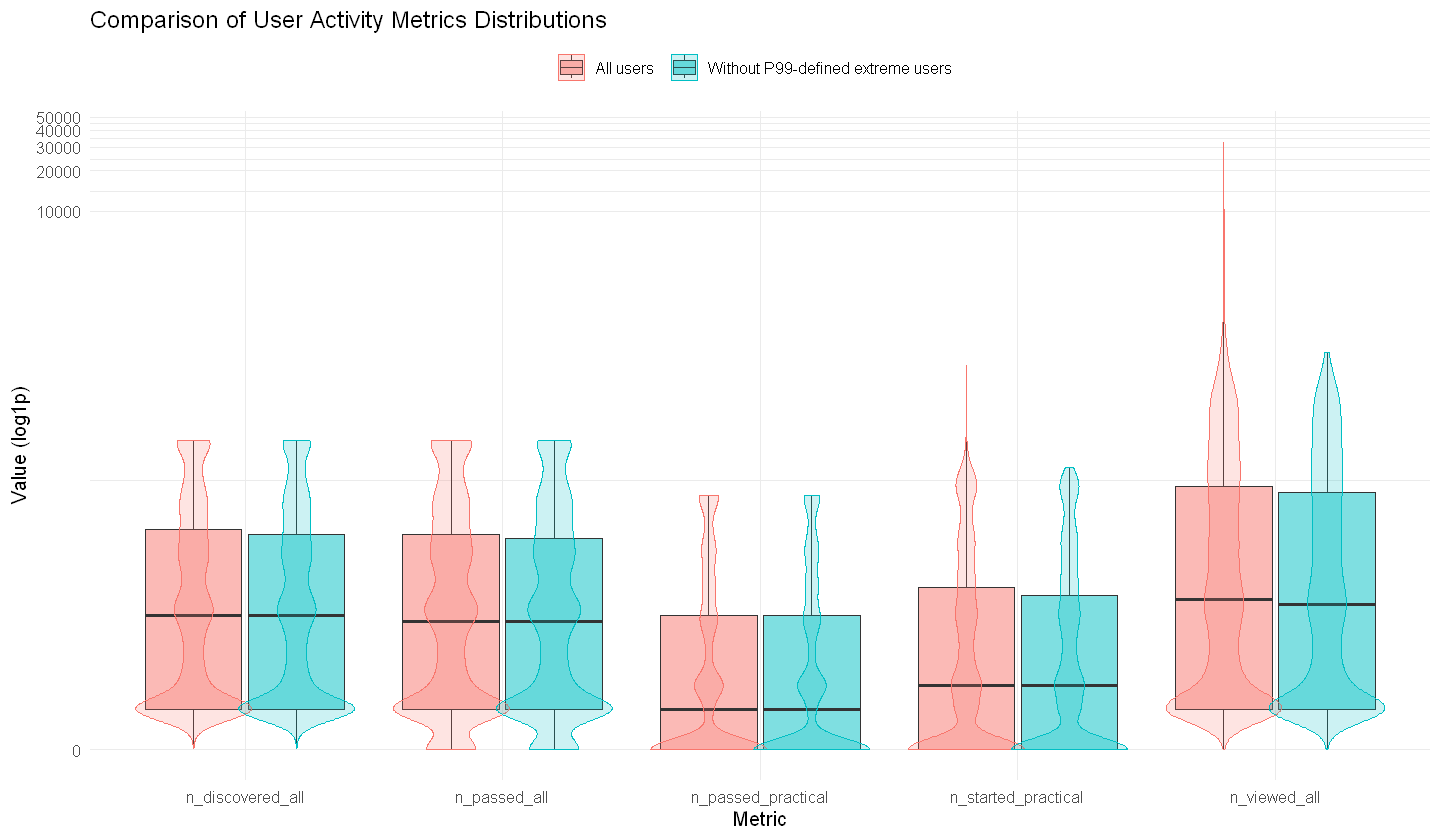

In [65]:
# Plot size for user activity distribution chart
options(repr.plot.width = 12, repr.plot.height = 7)

# Create combined violin-boxplot for user activity metrics
ggplot(plot_data, aes(x = metric, y = value, fill = type)) +
  geom_boxplot(outlier.shape = NA, alpha = 0.5, position = position_dodge(width = 0.8)) +
  geom_violin(aes(color = type), alpha = 0.2, position = position_dodge(width = 0.8), scale = "width") +
  scale_y_continuous(trans = 'log1p') + 
  labs(
    title = "Comparison of User Activity Metrics Distributions",
    x = "Metric",
    y = "Value (log1p)",
    fill = "",
    color = ""
  ) +
  theme_minimal(base_size = 12) +
  theme(legend.position = "top")

**Visual Distribution Analysis: Shape of Engagement**

The violin plots show that P99-defined extreme users mainly affect the upper tail of the distribution. After filtering, the maximum value of `n_viewed_all` decreases from **32,778 to 899**, while the main density of users remains concentrated in the low-activity range.

This confirms that outlier filtering reduces scale distortion but does not change the core behavioral pattern. Low practical engagement persists after filtering: the inactive rate for `n_started_practical` changes only slightly from **40.73% to 41.38%**. Therefore, the activation bottleneck should be interpreted as a structural engagement issue rather than as an artifact of extreme users.

#### Comparing Mean And Median For All Users vs. Excluding P99-defined extreme users

In [66]:
# Select mean and median from both data frames
dt_all <- actions_diagnostic[, .(metric, mean, median)][, type := "All users"]
dt_no99 <- actions_diagnostic_no99p[, .(metric, mean, median)][, type := "Without P99-defined extreme users"]

In [67]:
# Transform data to long format
plot_bar_dt <- melt(rbind(dt_all, dt_no99), 
                    id.vars = c("metric", "type"), 
                    measure.vars = c("mean", "median"), 
                    variable.name = "stat_type", 
                    value.name = "value")

In [68]:
# Add suitable names
plot_bar_dt[, stat_label := ifelse(stat_type == "mean", "Mean", "Median")]

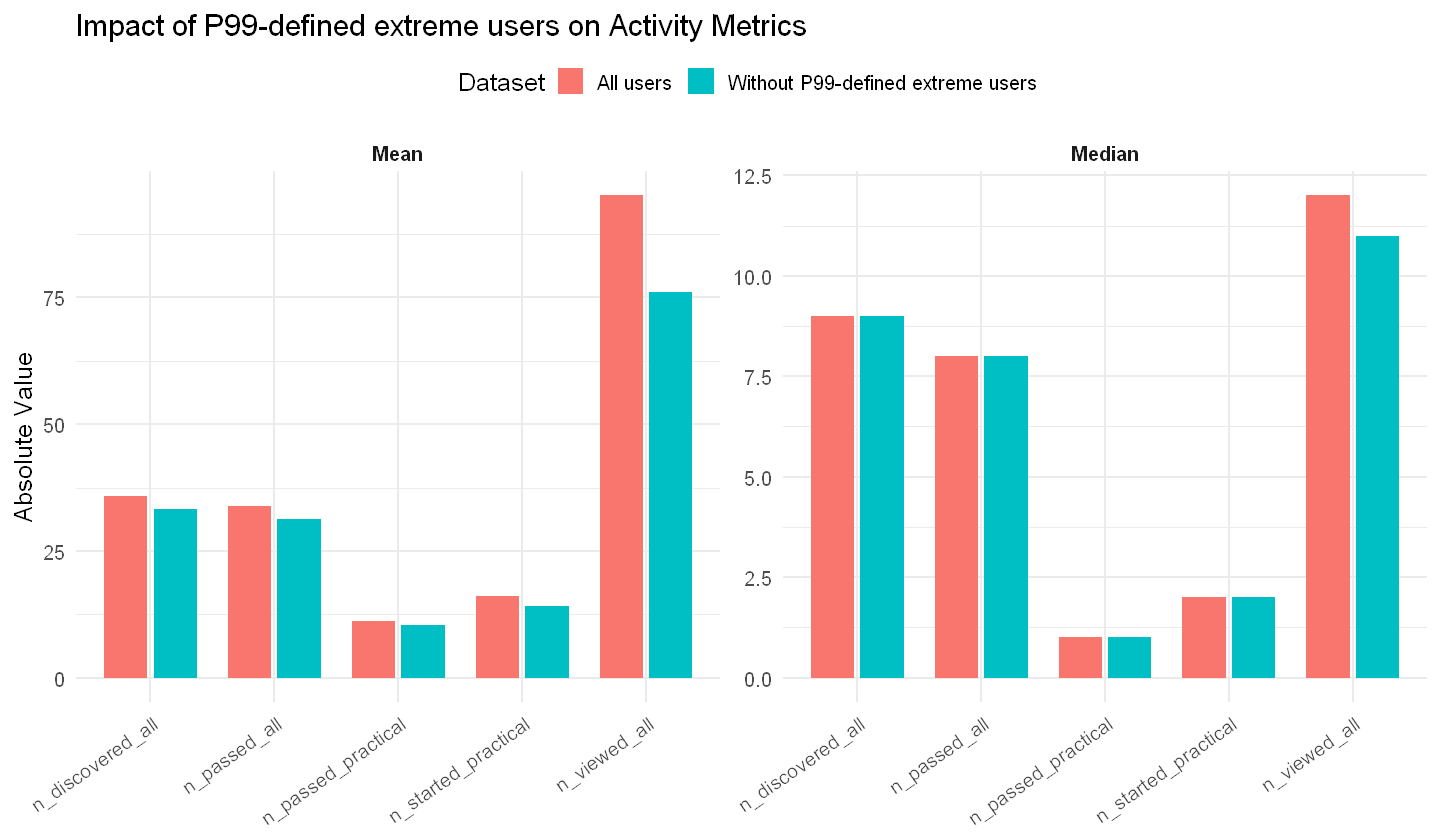

In [69]:
# Plot size for user activity distribution chart
options(repr.plot.width = 12, repr.plot.height = 7)

# Create combined barplot for user activity metrics
ggplot(plot_bar_dt, aes(x = metric, y = value, fill = type)) +
  geom_bar(stat = "identity", position = position_dodge(width = 0.8), width = 0.7) +
  facet_wrap(~stat_label, scales = "free_y") + 
  theme_minimal(base_size = 15) +
  scale_fill_manual(values = c("#F8766D", "#00BFC4")) +
  labs(
    title = "Impact of P99-defined extreme users on Activity Metrics",
    x = NULL,
    y = "Absolute Value",
    fill = "Dataset"
  ) +
  theme(
    legend.position = "top",
    axis.text.x = element_text(angle = 35, hjust = 1),
    strip.text = element_text(face = "bold") 
  )

**Metrics Reliability: Mean vs. Median**

The comparison between mean and median shows that average-based metrics are more sensitive to the extreme high-activity tail, while median values remain relatively stable and better represent typical user behavior.

* **Mean Sensitivity:**  
  After P99 filtering, the mean of `n_viewed_all` decreases from **95.1 to 76.0**. This confirms that the full-sample mean is influenced by a small group of extremely active users, especially for repeatable actions such as views.

* **Median Stability:**  
  The median of `n_viewed_all` changes only slightly from **12 to 11**. For practical engagement metrics, the medians remain stable: `n_started_practical` stays at **2**, and `n_passed_practical` stays at **1**.

**Conclusion:**  
P99 filtering reduces distortion in mean-based metrics, but it does not materially change the typical learner profile. This supports the conclusion that low practical engagement is a structural pattern rather than an artifact of extreme users.

>**Technical Note: Mapping Flag `is_extreme`**
>
>The `is_extreme` flag is retained in the master `user_metrics` table for transparency, auditability, and reproducible filtering. It identifies users flagged by the P99-based high-activity rule and supports comparison between high-activity and typical-user segments.
>
>In this project, the flag is mainly used for sensitivity checks and for constructing the P99-filtered downstream modeling sample. It also keeps open the option for a separate follow-up analysis of high-activity trajectories, such as comparing practical engagement, submission intensity, score accumulation, or completion outcomes. This separate subgroup analysis is outside the current project scope.

---

> **Technical Note: Secondary Metrics**
>
> Several additional **user-level** metrics are retained for downstream **clustering** and **supervised modeling**. They are not central to diagnosing the immediate "cold start" bottleneck, but they provide useful signals for **Behavioral Clustering**, **Predictive Modeling**, and contextual interpretation of **step-level engagement patterns**.

| Metric | Definition |
| :--- | :--- |
| `active_days` | Consistency: number of unique calendar days with any recorded event or submission. |
| `course_duration` | Inclusive calendar span from first to last recorded activity, with a minimum value of 1 day. |
| `median_gap_days` | Learning rhythm: median number of days between consecutive active calendar days. |
| `view_frequency` | Viewing intensity: total views divided by course duration. |
| `submission_frequency` | Submission intensity: total submissions divided by course duration. |
| `steps_per_active_day` | Progress velocity: total passed events divided by active days. |
| `submission_correct_rate` | Submission efficiency: correct submissions divided by total submissions. |
| `n_submissions` | Total number of solution attempts submitted. |
| `last_timestamp` | Date and time of the user's final recorded activity. |
| `last_step_id` | Final observed step ID in the available activity log. |


---

## Step-Level Analysis

>**Methodological Note (Population Scope):**
>
>The reconstructed course sequence and scoring architecture are derived from the full available event/submission structure. However, behavioral step-level metrics in this section — including views, starts, pass rates, traffic ratios, final exits, grinding, and cross-audit signals — are computed using the P99-filtered analytical user sample (extreme users excluded). This improves robustness of engagement estimates but may underrepresent high-intensity usage patterns.

### Reconstructing Course Sequence

>**Technical Note: Course Sequence Reconstruction**
>
>This reconstruction uses the full user population because the goal is to infer course structure rather than estimate behavioral intensity.
>
>**Problem:** The anonymized `step_id` values do not follow a chronological or numerical order, making it impossible to visualize the student journey using raw IDs.
>
>**Solution:** To support sequence-aware drop-off and step-level analysis, a **Course Order (1–198)** was reconstructed using **Average Encounter Ranking**. 
>
>**Methodology:**
>1. **Rank Calculation:** For every user, each step was assigned a rank based on the order in which it first appeared in their activity logs.
>2. **Global Aggregation:** The estimated position of a step was inferred by calculating its **mean rank** across the entire student population.
>3. **Sequence Mapping:** Steps were then sorted by these mean ranks and indexed from **1 to 198**.
>
>**Result:** This derived sequence provides a stable chronological baseline for identifying specific friction points and measuring the exact stage at which users churn.

In [70]:
# Find the first timestamp for each user-step interaction
step_first_encounter <- events_data[, .(first_time = min(timestamp_dt)), by = .(user_id, step_id)]

In [71]:
# Rank steps for each user based on encounter time
step_first_encounter[, user_step_rank := frank(first_time), by = user_id]

In [72]:
# Average individual ranks to determine the global pedagogical sequence
step_sequence <- step_first_encounter[, .(
  avg_rank = mean(user_step_rank)
), by = step_id][order(avg_rank)]

In [73]:
# Assign final ordinal position (1 to 198)
step_sequence[, course_order := 1:.N]

In [74]:
# Validate reconstructed course sequence length and continuity
stopifnot(nrow(step_sequence) == 198)
stopifnot(max(step_sequence$course_order) == 198)
stopifnot(identical(step_sequence$course_order, 1:198))

---

### Step Scoring Architecture

>**Technical Note: Assignment Scoring Architecture**
>
>Raw `step_id` metadata does not contain assignment score weights, and the anonymized data does not provide direct access to the original curriculum metadata. Therefore, assignment scores were reconstructed manually using the ordinal sequence of practical, submission-enabled steps.
>
>The practical assignment sequence was derived by selecting all steps from the reconstructed course sequence that appear in `submissions_data`. This is appropriate because `submissions_data` contains only steps that accept practical submissions. A prior consistency check confirmed that these steps match the set of `started_attempt` steps in `events_data`.
>
>Scores were then assigned by practical-assignment order rather than by raw `step_id`, since raw IDs are platform-wide, non-sequential, and not meaningful as course positions. This mapping allows score-weighted progress metrics to be calculated, including total earned points, completion status, and score-based productivity.
>
>Because score weights were reconstructed manually rather than obtained directly from platform metadata, score-based analyses should be interpreted as approximate.

In [75]:
# Select assignment steps from the reconstructed course sequence
practical_steps_sequence <- step_sequence[
  step_id %in% assignment_step_ids,
  .(step_id, course_order)
]

In [76]:
# Manually defined score mapping by practical-assignment order
# 0-point assignments represent non-graded tasks (e.g., introductory or practice steps)
# designed to help users learn the platform mechanics or warm up before scored tasks.
score <- list(
  `0` = c(2,3),
  `1` = c(1,4,5,6,7,8,9,10,11,12,13,14,15,17,18,19,20,21,
          22,23,24,26,27,28,29,30,31,32,33,34,35,37,39,40,41,
          42,43,47,46,48,51,53,54,55,56,57,58,59,60,61,
          62,63,64,65,66,67,68,69,70,73,74,75),

  `2` = c(16,25,36,38,44,45,49,52,71,76),

  `3` = c(50,72)
)

In [77]:
# Match score to steps
practical_steps_sequence[, step_score := 0L]

for (points in names(score)) {
  practical_steps_sequence[score[[points]], step_score := as.integer(points)]
}

In [78]:
# Initialize the main step_metrics table
step_metrics <- step_sequence[, .(step_id, course_order)]

In [79]:
# Map point weights to the course sequence table
step_metrics[practical_steps_sequence, on = "step_id", step_score := i.step_score]

In [80]:
# Fill missing scores with 0 for non-assignment steps (e.g., videos or texts)
step_metrics[is.na(step_score), step_score := 0L]

In [81]:
# Flag assignment steps using the validated canonical step list
step_metrics[, is_assignment := step_id %in% assignment_step_ids]

In [82]:
# Validate assignment-step identification and reconstructed score weights
stopifnot(
  sum(step_metrics$is_assignment) ==
    length(assignment_step_ids),

  setequal(
    step_metrics[is_assignment == TRUE, step_id],
    assignment_step_ids
  ),

  sum(step_metrics[is_assignment == TRUE, step_score]) == 88L
)

---

### Step-Level Metrics Aggregation

In [83]:
# Metrics Aggregation
# P99-filtered step-level metrics are calculated from the filtered raw datasets.

# Unique viewers of each step
step_views <- events_data_no_extreme[
  action == "viewed",
  .(n_viewed = uniqueN(user_id)),
  by = step_id
]

# Unique users who started an assignment attempt
step_starts <- events_data_no_extreme[
  action == "started_attempt",
  .(n_started_assignment = uniqueN(user_id)),
  by = step_id
]

# Unique users with at least one correct submission on the assignment step
step_success <- submissions_data_no_extreme[
  submission_status == "correct",
  .(n_passed_assignment = uniqueN(user_id)),
  by = step_id
]

# Average number of submissions per submitting user on each assignment step
grinding_dt <- submissions_data_no_extreme[
  ,
  .(avg_submissions_per_user = .N / uniqueN(user_id)),
  by = step_id
]

In [84]:
# Join all metrics into step_metrics
step_metrics[step_views,   on = "step_id", n_viewed := i.n_viewed]
step_metrics[step_starts,  on = "step_id", n_started_assignment := i.n_started_assignment]
step_metrics[step_success, on = "step_id", n_passed_assignment := i.n_passed_assignment]
step_metrics[grinding_dt,  on = "step_id", avg_submissions_per_user := i.avg_submissions_per_user]

In [85]:
# Replace missing values for steps with no recorded activity
cols_to_fix <- c(
  "n_viewed",
  "n_started_assignment",
  "n_passed_assignment",
  "avg_submissions_per_user"
)

for (j in cols_to_fix) {
  set(step_metrics, which(is.na(step_metrics[[j]])), j, 0)
}

In [86]:
# Calculate assignment conversion rates and aggregate step-to-step traffic ratio
setorder(step_metrics, course_order)

step_metrics[, `:=`(
  # Share of step viewers who started an assignment attempt.
  # Meaningful primarily for assignment steps.
  start_rate = n_started_assignment / pmax(n_viewed, 1),

  # Share of users who started an assignment attempt and later achieved
  # at least one correct submission on the same step.
  # Meaningful primarily for assignment steps.
  pass_rate = n_passed_assignment / pmax(n_started_assignment, 1),

  # Aggregate viewer-volume ratio between the next reconstructed course step
  # and the current step. This is a traffic-flow metric, not individual-level retention.
  step_to_step_traffic_ratio = shift(n_viewed, type = "lead") / pmax(n_viewed, 1)
)]

---

>**Step Metrics Data Dictionary (Final Dataset Schema)**
>
>This table provides a comprehensive overview of the features calculated for each step in the curriculum. These metrics evaluate the difficulty, engagement, and attrition levels at a granular level.

| Metric | Definition | 
| :--- | :--- |
| `step_id` | **Unique identifier** for each step in the course. |
| `course_order` | **The chronological sequence** of the step. | 
| `step_score` | **Score value** assigned to the task. | 
| `is_assignment` | Boolean flag (True/False) **if the step is a task**. | 
| `n_viewed` | **Unique users who viewed** the step. | 
| `n_started_assignment` | **Users who engaged with the task** (including those who did not submit a solution). | 
| `n_passed_assignment` | **Unique users with at least one correct submission** on the assignment step. |
 | `start_rate` | **Ratio of users starting a task vs viewing it**. | 
| `pass_rate` | **Ratio of users passing vs starting the step.** | 
| `step_to_step_traffic_ratio` | **Ratio of unique viewers of the next step to unique viewers of the current step**. | 
| `avg_submissions_per_user` | **Average number of submissions per submitting user** on an assignment step. |

---

### Course Health Check (Step-to-Step Traffic Ratio)

In [87]:
# Shapiro-Wilk Test for the Green Corridor metric
traffic_values <- step_metrics[
  !is.na(step_to_step_traffic_ratio),
  step_to_step_traffic_ratio
]

shapiro_res <- shapiro.test(traffic_values)

In [88]:
# Clean Output
cat("=== SHAPIRO-WILK TEST: step_to_step_traffic_ratio ===\n")
cat(sprintf("P-value: %e\n", shapiro_res$p.value))
cat("--------------------------------------------\n")

if (shapiro_res$p.value < 0.05) {
    cat("RESULT: NOT NORMAL (p < 0.05).\n")
} else {
    cat("RESULT: NORMAL (p >= 0.05). \n")
}

=== SHAPIRO-WILK TEST: step_to_step_traffic_ratio ===
P-value: 9.874980e-18
--------------------------------------------
RESULT: NOT NORMAL (p < 0.05).


> **Methodological Note: Step-to-Step Traffic Ratio (Robust Analysis)**
>
> This section analyzes aggregate viewer-flow changes across the reconstructed course sequence. The `step_to_step_traffic_ratio` compares viewer volume on the next step with viewer volume on the current step. It is therefore interpreted as a traffic-flow metric, not as individual-level retention.
>
> Since the Shapiro-Wilk test indicates a non-normal distribution, and because traffic ratios are sensitive to non-linear navigation and outliers, a robust MAD-based approach is used instead of a standard deviation threshold.
>
> The analysis applies a **Hampel-style approach**:
>
> * **Median baseline:** used as a robust center of typical traffic-flow behavior.
> * **MAD threshold:** used to define a robust reference band.
> * **±3 MAD reference rule:** used to identify unusually low and high traffic-flow deviations. Lower-bound deviations are included in the cross-diagnostic audit, while upper-bound deviations are retained as contextual indicators in the visualization.
>
> Lower-bound outliers are interpreted as potential aggregate traffic drops and are included in the prioritized cross-audit. Upper-bound outliers are interpreted as contextual traffic spikes that may reflect non-linear navigation, direct access, revisits, curriculum changes, or tracking effects.

In [89]:
# Using Median as the baseline is resilient to skewed data and outliers
med_ret <- median(step_metrics$step_to_step_traffic_ratio, na.rm = TRUE)
mad_ret <- mad(step_metrics$step_to_step_traffic_ratio, na.rm = TRUE)

In [90]:
# Define the "Robust Green Corridor" boundaries
# Using a 3-MAD threshold (equivalent to high-sensitivity anomaly detection)
lower_bound <- med_ret - (mad_ret * 3)
upper_bound <- med_ret + (mad_ret * 3)

In [91]:
# Calculate Robust Z-score (Modified Z-score)
# This identifies specific outliers by measuring deviations from the Median
step_metrics[, robust_z_score :=
  (step_to_step_traffic_ratio - med_ret) / mad_ret
]

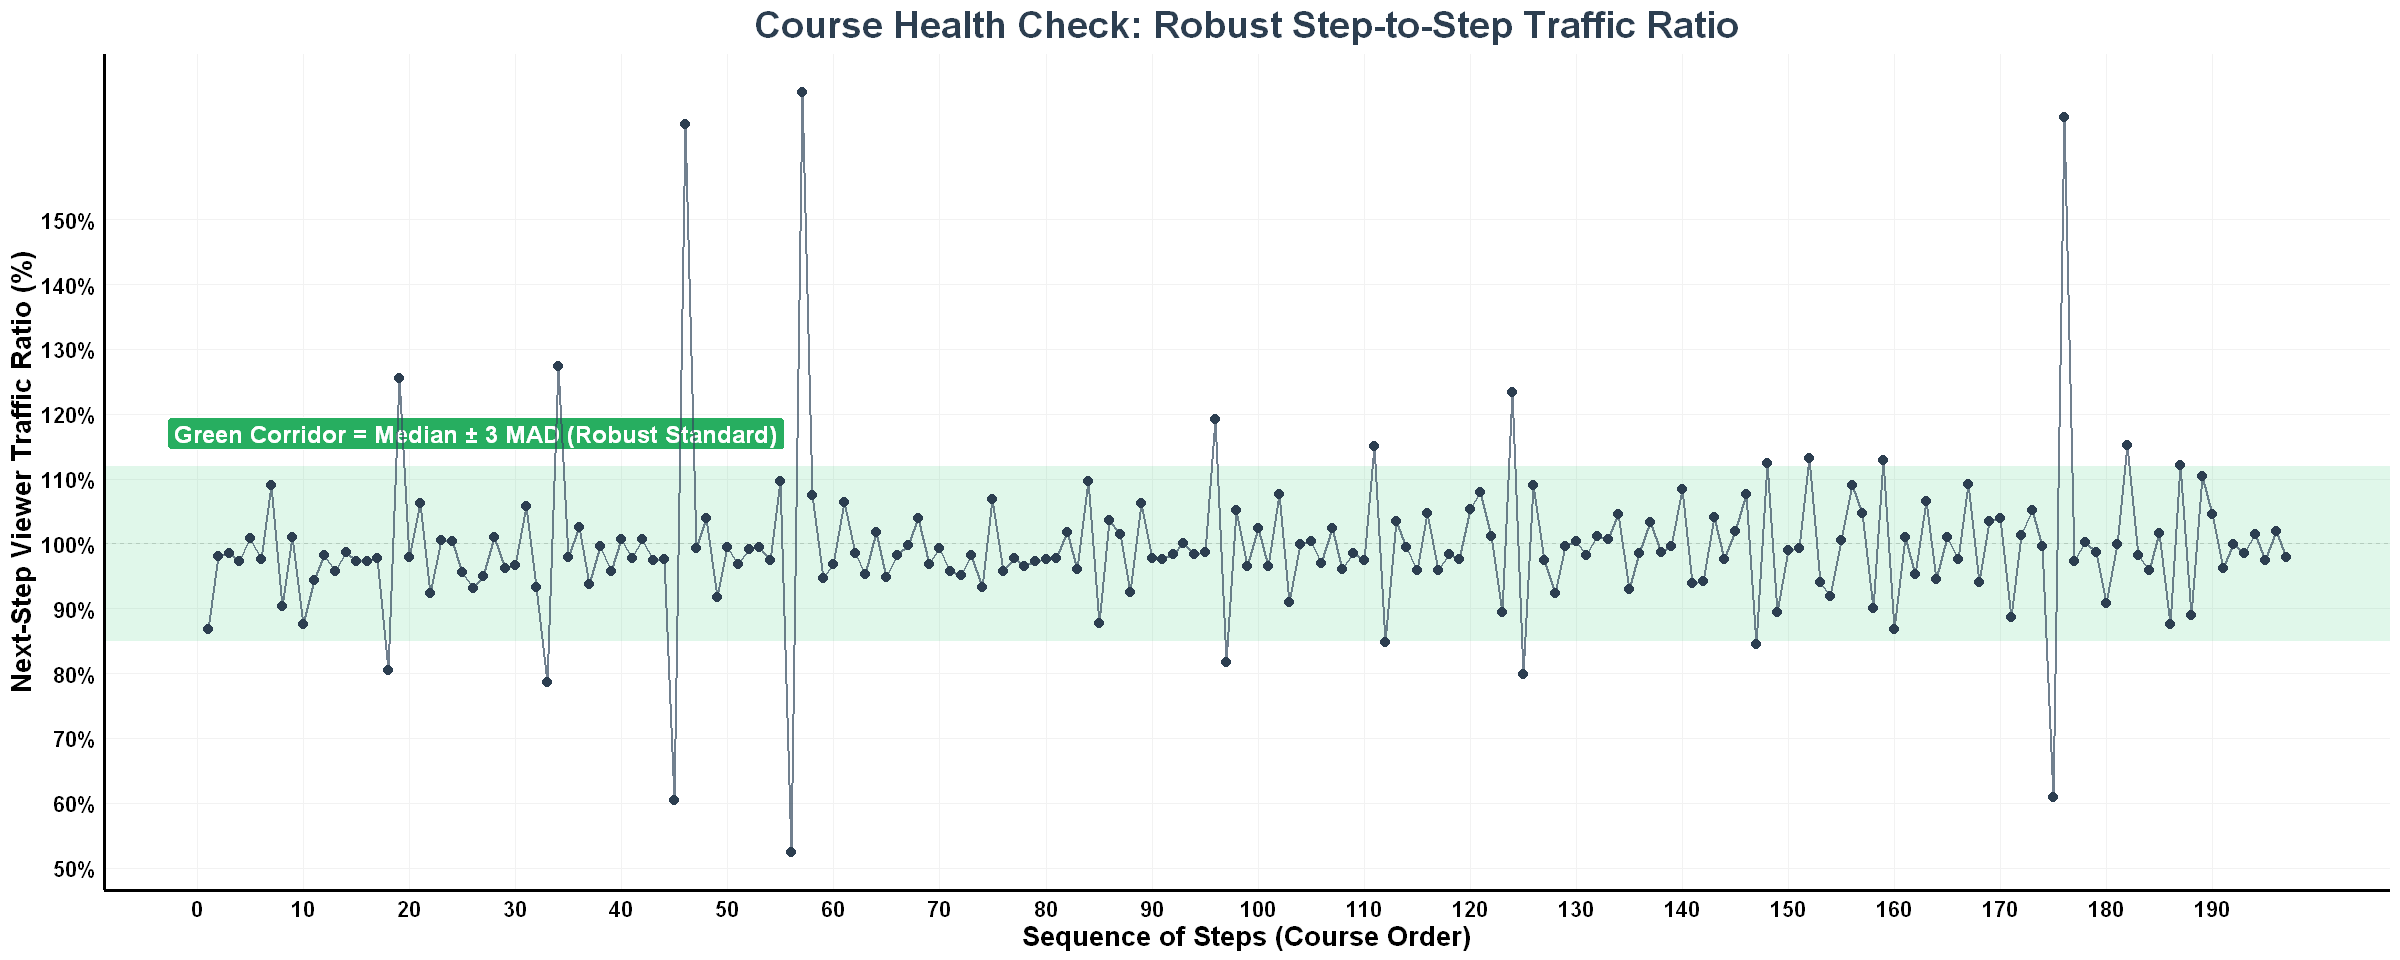

In [92]:
# Visualization Settings
options(repr.plot.width = 20, repr.plot.height = 8)

# Plot Generation
ggplot(step_metrics[!is.na(step_to_step_traffic_ratio)], aes(x = course_order, y = step_to_step_traffic_ratio)) +
  
  # Reference line at 100%
  geom_hline(yintercept = 1.0, linetype = "dashed", color = "grey80", linewidth = 0.5) +
  
  # The Robust Green Corridor (± 3 MAD)
  # Represents the statistical norm adjusted for non-normal distribution
  annotate("rect", xmin = -Inf, xmax = Inf, 
           ymin = lower_bound, ymax = upper_bound, 
           fill = "#2ecc71", alpha = 0.15) +
  
  # Label updated for Robust Methodology
  # Positioned slightly above the upper bound
  annotate("label", x = 3, y = upper_bound + 0.05, 
           label = "Green Corridor = Median ± 3 MAD (Robust Standard)", 
           fill = "#27ae60", color = "white", fontface = "bold", size = 5, hjust = 0.1) +
  
  # Data points and trend line
  geom_line(color = "#34495e", linewidth = 0.6, alpha = 0.7) + 
  geom_point(color = "#2c3e50", size = 2.5) +
  
  # Axis Scaling
  scale_y_continuous(labels = scales::percent_format(), 
                     breaks = seq(0, 1.5, by = 0.1)) +
  scale_x_continuous(breaks = seq(0, max(step_metrics$course_order, na.rm = TRUE), by = 10)) +
  
  # Styling
  theme_minimal() +
  theme(
    axis.text.x = element_text(color = "black", size = 13, face = "bold"),
    axis.text.y = element_text(color = "black", size = 13, face = "bold"),
    axis.line = element_line(color = "black", linewidth = 1),
    axis.title = element_text(size = 16, face = "bold", color = "black"),
    plot.title = element_text(size = 22, face = "bold", hjust = 0.5, color = "#2c3e50"),
    panel.grid.minor = element_blank(),
    panel.grid.major = element_line(color = "grey95")
  ) +
  labs(
    title = "Course Health Check: Robust Step-to-Step Traffic Ratio",
    x = "Sequence of Steps (Course Order)", 
    y = "Next-Step Viewer Traffic Ratio (%)"
  )

**Visual Interpretation: Step-to-Step Traffic Ratio**

> **Executive Summary:**
>
> Most adjacent-step traffic ratios remain within the robust green corridor, suggesting generally stable aggregate viewer flow across the reconstructed course sequence. The main exceptions are localized drops and spikes, which point to specific steps that should be reviewed manually rather than to a uniform course-wide failure.

**Interpretation**

The chart shows that most adjacent-step traffic ratios stay inside the green corridor, defined as `median ± 3 × MAD`. This indicates that, for most neighboring steps, aggregate viewer flow changes within the expected robust range.

Several localized deviations are visible. Sharp drops to roughly **50–60%** indicate steps after which downstream viewer traffic decreases substantially. These points may represent structural or behavioral friction points where users interrupt their progression.

Spikes above **150%** suggest non-linear navigation. In these cases, more users appear on the next reconstructed step than on the previous one, which may reflect direct access, revisits, bookmarks, resumed sessions, curriculum changes, or tracking effects.

Later-course fluctuations should be interpreted cautiously because the viewer base becomes smaller, so individual step-level changes can produce larger traffic-ratio swings.

Overall, the graph suggests that traffic loss is not evenly distributed across the course. Instead, the strongest deviations are concentrated around specific steps that should be reviewed manually.

**Actionable Follow-Up**

- **High priority:** audit steps below the lower MAD boundary to identify possible interruption or drop-off points.
- **Medium priority:** review steps above the upper MAD boundary to validate tracking logic and better understand non-linear navigation behavior.

### Anomaly Extraction

In [93]:
# Identify steps with critical aggregate traffic drops (Lower Bound Outliers).
# These steps show a sharp decrease in viewer volume from the current step
# to the next reconstructed course step and should be reviewed as potential
# flow interruption points.
low_zscore_steps <- step_metrics[step_to_step_traffic_ratio < lower_bound, .(
  type = "TRAFFIC_DROP",
  step_id, 
  course_order,
  is_assignment,
  traffic_ratio_pct = round(step_to_step_traffic_ratio * 100, 1),
  avg_submissions_per_user = round(avg_submissions_per_user, 2), 
  robust_z_score = round(robust_z_score, 2),  
  n_viewed
)]

# Only lower-bound traffic drops are included in the cross-audit.
# Upper-bound traffic spikes remain visible in the diagnostic chart
# as contextual indicators of non-linear navigation.

In [94]:
# Sort by traffic ratio to prioritize the strongest viewer-flow drops.
setorder(low_zscore_steps, traffic_ratio_pct)

---

### Identify the Top 10 Final Observed Steps by User Count

In [95]:
# Top-10 final observed steps by user count
# Calculated from the P99-filtered user-level dataset
top_last_steps <- user_metrics_no_extreme %>%
  count(step_id = last_step_id) %>%
  arrange(desc(n)) %>%
  slice_head(n = 10) %>%
  left_join(
    step_metrics[, .(step_id, course_order, is_assignment)] %>% distinct(),
    by = "step_id"
  ) %>%
  mutate(
    step_type = factor(
      ifelse(is_assignment, "Assignment", "Theory/Video"),
      levels = c("Theory/Video", "Assignment")
    )
  )

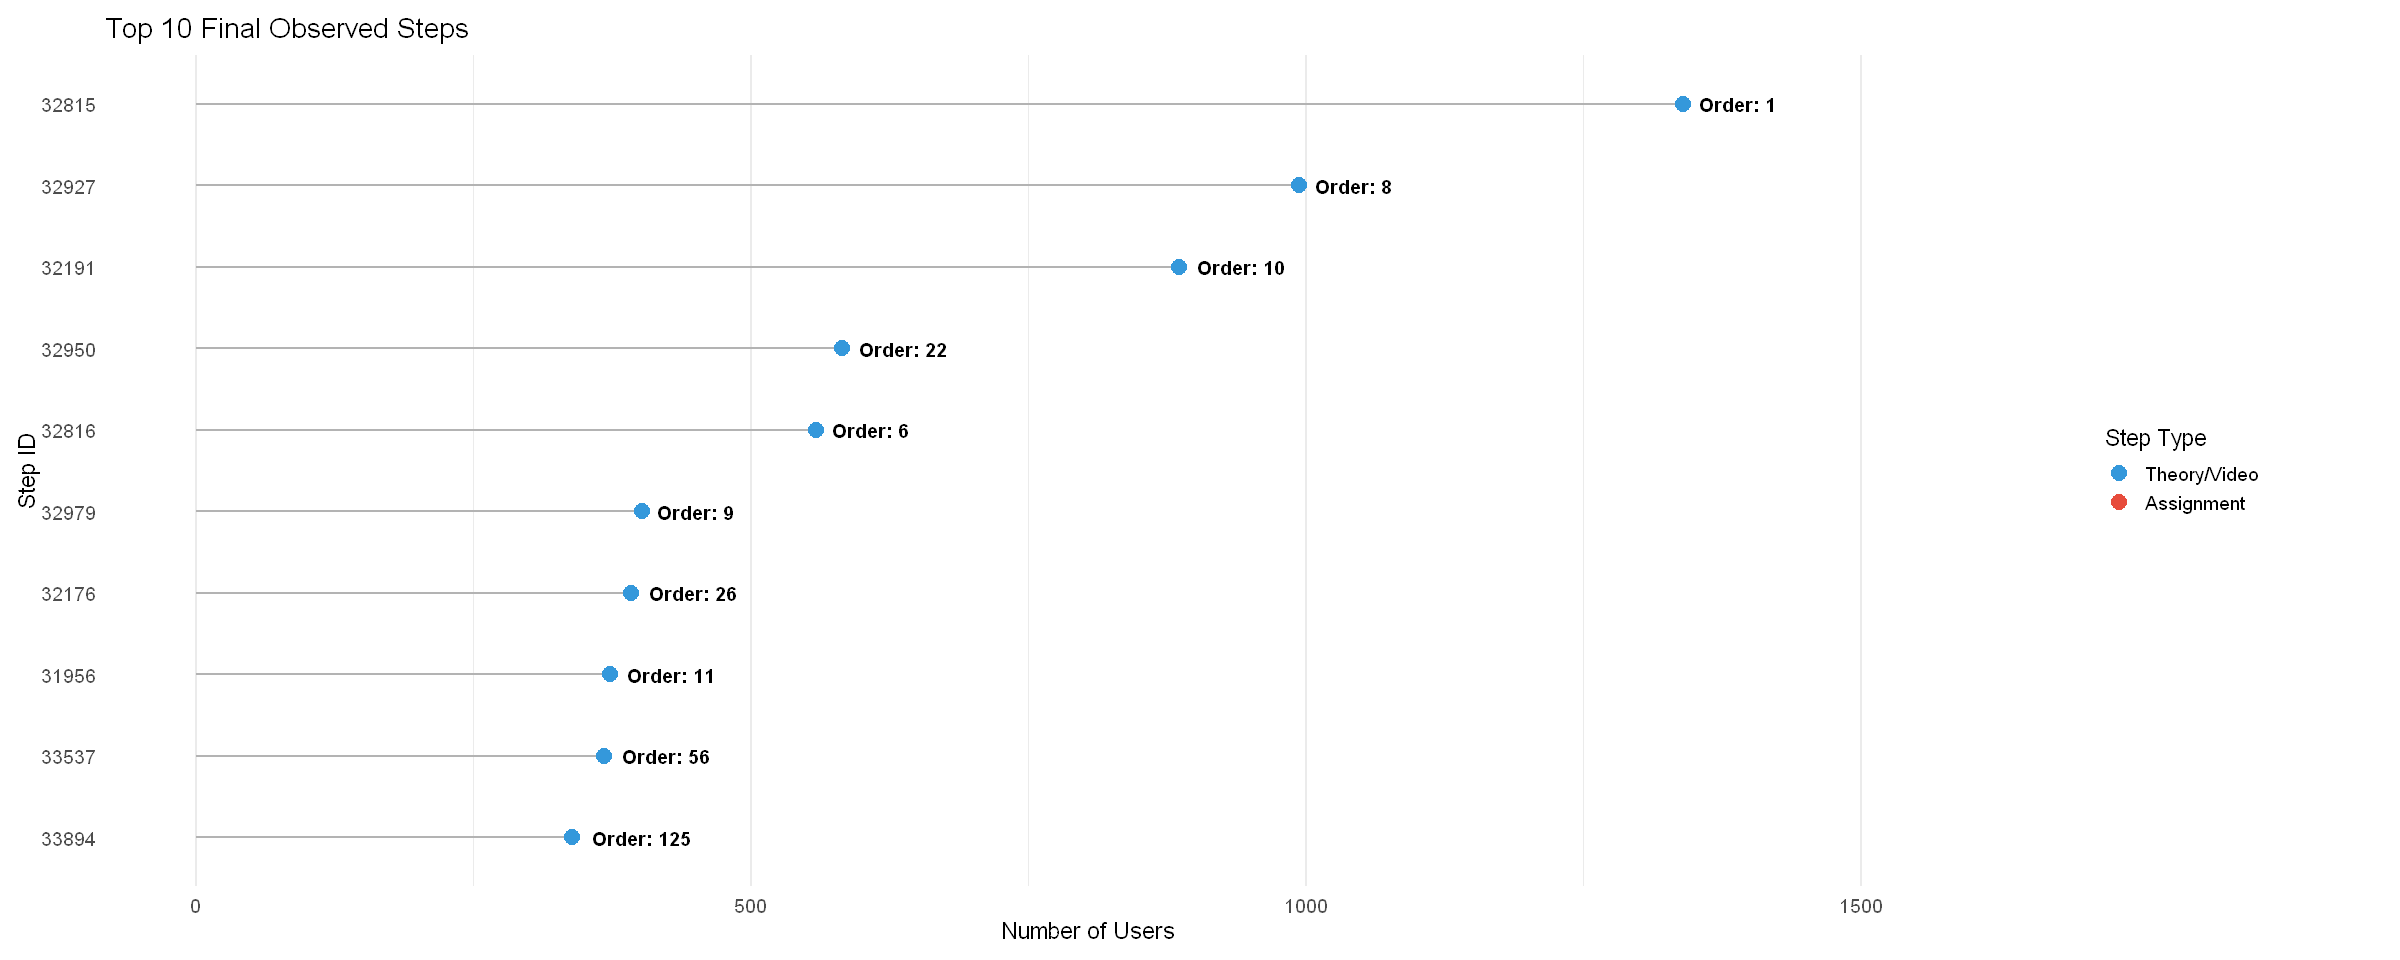

In [96]:
# Plot the top 10 final observed steps
ggplot(top_last_steps, aes(x = reorder(as.factor(step_id), n), y = n)) +

  # Draw lollipop stems
  geom_segment(
    aes(xend = as.factor(step_id), yend = 0),
    color = "gray70"
  ) +

  # Add points colored by step type
  geom_point(
    aes(color = step_type),
    size = 4,
    show.legend = TRUE
  ) +

  # Flip axes for readability
  coord_flip(clip = "off") +

  # Set colors and legend order
  scale_color_manual(
    limits = c("Theory/Video", "Assignment"),
    breaks = c("Theory/Video", "Assignment"),
    values = c(
      "Theory/Video" = "#3498DB",
      "Assignment" = "#E74C3C"
    ),
    drop = FALSE,
    guide = guide_legend(
      override.aes = list(
        alpha = 1,
        size = 4
      )
    )
  ) +

  # Add course-order labels
  geom_text(
    aes(label = paste0("Order: ", course_order)),
    hjust = -0.2,
    size = 4,
    fontface = "bold"
  ) +

  # Add space for labels
  expand_limits(y = max(top_last_steps$n) * 1.2) +

  # Add titles and axis labels
  labs(
    title = "Top 10 Final Observed Steps",
    x = "Step ID",
    y = "Number of Users",
    color = "Step Type"
  ) +

  # Apply minimal styling
  theme_minimal(base_size = 14) +
  theme(
    panel.grid.major.y = element_blank(),
    plot.margin = margin(10, 80, 10, 10)
  )

**Top 10 Final Observed Steps**

This analysis highlights where users in the P99-filtered analytical sample most frequently stop their activity in the course.

> **Executive Summary: Early Exit Concentration**
>
> The most frequent final observed steps are mainly associated with **theory/video content**. The largest exit point occurs at the very beginning of the course, while several other frequent exits appear in the early course sequence. This suggests that disengagement is primarily linked to early-stage orientation and passive-content consumption rather than assignment-specific failure.

---

**Key Observations:**

* **First-Step Bounce:**  
  The largest number of users stop at **Order: 1**, indicating a strong initial drop-off point.

* **Early-Stage Concentration:**  
  Several top exit points occur within the first reconstructed steps, especially around **Orders 6–10**.

* **Theory/Video Dominance:**  
  All top-10 final observed steps in this view are classified as **theory/video steps**.

* **Later Isolated Exits:**  
  A few later steps, such as **Orders 56 and 125**, also appear among the top final observed steps, but they are less dominant than the early-course exit points.

---

**Key Insight:**

Drop-off is primarily driven by **early-stage engagement and onboarding issues**. The evidence here points more strongly to a theory-to-practice activation problem than to assignment-level difficulty.

---

### Step-Level Performance Understanding (Assignments Only)

> **Methodological Note: Practice Layer Analysis**
>
> This section focuses on the practical-assignment layer of the course. Course completion requires active interaction with assignments, but many users either never reach this layer or engage with it only minimally.
>
> Using the P99-filtered step-level metrics, the analysis isolates **76 assignment steps** to establish a practical-engagement baseline for typical learner behavior.
>
> The goal is to identify where practical activation is weak and where assignment-level friction may prevent users from moving beyond passive content viewing.

In [97]:
# Summarize assignment-level engagement, conversion, traffic-flow, and effort metrics
summary(step_metrics[
  is_assignment == TRUE,
  .(
    n_viewed,
    n_started_assignment,
    n_passed_assignment,
    start_rate,
    pass_rate,
    step_to_step_traffic_ratio,
    avg_submissions_per_user
  )
])

    n_viewed    n_started_assignment n_passed_assignment   start_rate    
 Min.   :1401   Min.   :1175         Min.   :1004        Min.   :0.8070  
 1st Qu.:1573   1st Qu.:1415         1st Qu.:1294        1st Qu.:0.8953  
 Median :2154   Median :2009         Median :1762        Median :0.9255  
 Mean   :3061   Mean   :2822         Mean   :2573        Mean   :0.9136  
 3rd Qu.:3846   3rd Qu.:3502         3rd Qu.:3089        3rd Qu.:0.9371  
 Max.   :9770   Max.   :9140         Max.   :8750        Max.   :0.9648  
                                                                         
   pass_rate      step_to_step_traffic_ratio avg_submissions_per_user
 Min.   :0.8007   Min.   :0.6046             Min.   :1.018           
 1st Qu.:0.8848   1st Qu.:0.9771             1st Qu.:1.504           
 Median :0.9129   Median :1.0073             Median :1.941           
 Mean   :0.9057   Mean   :1.0069             Mean   :2.200           
 3rd Qu.:0.9280   3rd Qu.:1.0496             3rd Qu.:2.731

**Result Summary: Practice Layer Health**

The practical component appears healthy once users reach assignment steps. In the P99-filtered assignment-level sample, each assignment has substantial viewer volume: the mean number of unique viewers is approximately **3,061**, with a minimum of **1,401**.

The mean assignment `start_rate` is approximately **91.4%**. This metric compares `n_started_assignment` with `n_viewed`, so it indicates that most users who view an assignment proceed to initiate an attempt.

The mean assignment `pass_rate` is approximately **90.6%**. This suggests that, among users who start assignments, most are observed to pass them. Therefore, the assignment layer does not appear to be broadly unsolvable for users who reach and engage with it.

The median effort level is moderate: The median assignment averages **1.94** submissions per submitting user. However, the maximum value of **5.25** highlights a small number of higher-friction assignments that may require manual review.

The `step_to_step_traffic_ratio` has a mean of approximately **100.7%** and a median of **100.7%**, but some assignment steps exceed **100%**. This confirms that users do not always move through the reconstructed course sequence linearly. These cases may reflect revisits, resumed sessions, direct access, or changes in course structure.

Overall, the main issue does not appear to be that assignments are broadly too difficult once users enter the practice layer. Instead, the larger product problem is the **practical activation gap**: many users never reach meaningful assignment engagement, but those who do enter the assignment layer usually show strong intent and high observed solvability.

> **Technical Note: `NA` in `step_to_step_traffic_ratio`**
>
> The single `NA` in `step_to_step_traffic_ratio` corresponds to the final step in the reconstructed course sequence, where no next-step traffic ratio can be calculated.

### Identify assignment steps with low assignment pass rate

In [98]:
# Focus only on steps that are assignments (is_assignment == TRUE)
# Define the lower quartile (Q1) for `pass_rate` as threshold for problematic steps
q1 <- quantile(
  step_metrics$pass_rate[step_metrics$is_assignment == TRUE],
  probs = 0.25,
  na.rm = TRUE
)

In [99]:
# Filter steps: only assignments with `pass_rate` below Q1
low_completion_steps <- step_metrics %>%
    filter(is_assignment == TRUE) %>%
    filter(pass_rate < q1) %>%
    arrange(course_order)

In [100]:
# Compare score distributions across all assignments and low-pass assignments
cat("Assignment Score Distribution Across All Assignments\n")
step_metrics[is_assignment == TRUE] %>% count(step_score) %>% mutate(p = n / sum(n))

cat("Assignment Score Distribution in Steps with pass_rate below Q1")
low_completion_steps %>% count(step_score) %>% mutate(p = n / sum(n))

Assignment Score Distribution Across All Assignments


step_score,n,p
<int>,<int>,<dbl>
0,2,0.02631579
1,62,0.81578947
2,10,0.13157895
3,2,0.02631579


Assignment Score Distribution in Steps with pass_rate below Q1

step_score,n,p
<int>,<int>,<dbl>
1,13,0.68421053
2,5,0.26315789
3,1,0.05263158


In [101]:
# Calculate the low-pass risk ratio for 2-point vs. 1-point assignments
risk_ratio_2pt_vs_1pt <- (
  low_completion_steps[step_score == 2, .N] /
    step_metrics[
      is_assignment == TRUE & step_score == 2,
      .N
    ]
) / (
  low_completion_steps[step_score == 1, .N] /
    step_metrics[
      is_assignment == TRUE & step_score == 1,
      .N
    ]
)

round(risk_ratio_2pt_vs_1pt, 2)

[1] 2.38

**Structural Friction Analysis: Score Weight vs. Observed Assignment Friction**

> **Executive Summary: Higher-Weight Tasks as a Risk Zone**  
> The comparison between all assignments and low-pass assignments shows that higher-weight tasks are overrepresented among problematic steps. In particular, **2-point assignments** account for only **13.2%** of all practical assignments, but represent **26.3%** of the low-pass assignment subset. This suggests that higher-weight tasks are more likely to coincide with observed friction.

---

**Calculation Methodology**

To evaluate whether assignment score weight is associated with friction, a **risk ratio** approach was used.

* **Baseline Group:**  
  1-point assignments are used as the baseline because they represent the majority of the practical layer.

* **Problematic Step Definition:**  
  A problematic step is defined as an assignment falling into the bottom quartile of assignment pass rate.

* **Risk Ratio:**  
  For each score group, the probability of being classified as problematic is compared with the probability for 1-point assignments.

---

**Analysis Results**

| Score Weight | Total Steps | Problematic Steps | Probability of Friction | Risk Ratio vs. 1pt |
| :--- | ---: | ---: | ---: | ---: |
| **1 Point** | 62 | 13 | **21.0%** | **1.00** |
| **2 Points** | 10 | 5 | **50.0%** | **2.38x** |
| **3 Points** | 2 | 1 | **50.0%** | **2.38x** |

---

**Conclusion and Interpretation**

* **2-point assignments show elevated risk:**  
  A 2-point assignment is approximately **2.4 times more likely** to be classified as problematic than a 1-point assignment.

* **Friction is not evenly distributed:**  
  2-point tasks make up **13.2%** of all practical assignments but **26.3%** of problematic assignments, indicating disproportionate representation in the low-pass subset.

* **3-point results should be interpreted cautiously:**  
  Although 3-point assignments show the same observed risk ratio, there are only **2** such steps in the course. Therefore, this result should be treated as a small-sample signal rather than a stable pattern.

Overall, the result suggests that difficulty-related friction exists, but it is concentrated in a limited subset of higher-weight assignments rather than spread evenly across the course.

---

### Visualizing Assignment Steps with Low Pass Rates

In [102]:
# Prepare the data for visualization low_completion_steps
low_completion_steps_long <- low_completion_steps %>%
  arrange(course_order) %>%
  select(course_order, start_rate, pass_rate) %>%
  tidyr::pivot_longer(cols = c(start_rate, pass_rate), 
                      names_to = "metric", values_to = "value")

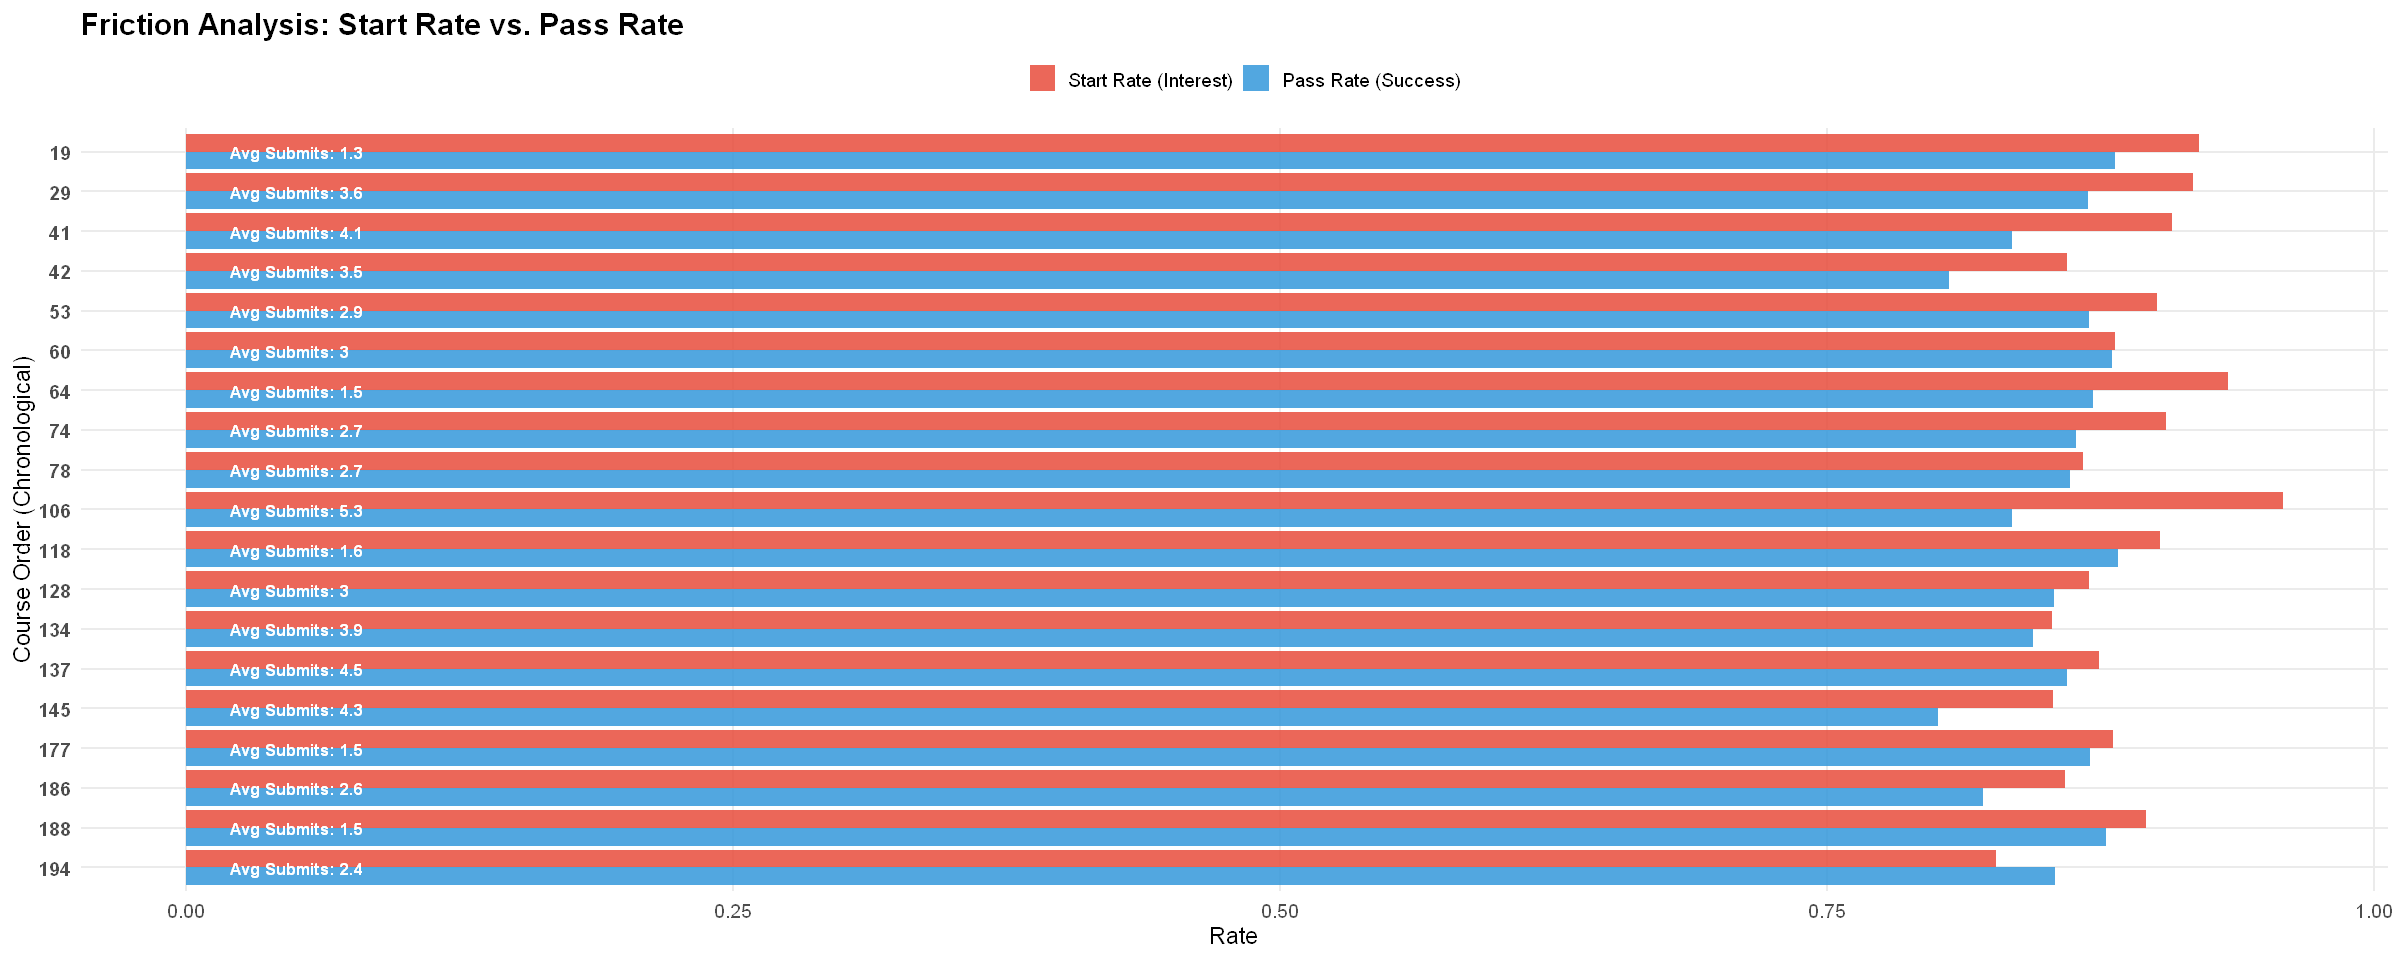

In [103]:
# Plot start and pass rates for low-completion steps
ggplot(
  low_completion_steps_long,
  aes(
    x = reorder(course_order, -course_order),
    y = value,
    fill = metric
  )
) +

  # Add rate bars
  geom_bar(
    stat = "identity",
    position = "dodge",
    alpha = 0.85
  ) +

  # Add average submission labels
  geom_text(
    data = low_completion_steps,
    aes(
      x = as.factor(course_order),
      y = 0.02,
      label = paste0(
        "Avg Submits: ",
        round(avg_submissions_per_user, 1)
      )
    ),
    inherit.aes = FALSE,
    hjust = 0,
    color = "white",
    fontface = "bold",
    size = 3.5
  ) +

  # Flip axes
  coord_flip() +

  # Set colors and legend labels
  scale_fill_manual(
    breaks = c("start_rate", "pass_rate"),
    values = c(
      "start_rate" = "#E74C3C",
      "pass_rate" = "#3498DB"
    ),
    labels = c(
      "Start Rate (Interest)",
      "Pass Rate (Success)"
    )
  ) +

  # Add titles and axis labels
  labs(
    title = "Friction Analysis: Start Rate vs. Pass Rate",
    x = "Course Order (Chronological)",
    y = "Rate",
    fill = ""
  ) +

  # Apply plot styling
  theme_minimal(base_size = 14) +
  theme(
    legend.position = "top",
    panel.grid.minor = element_blank(),
    axis.text.y = element_text(face = "bold"),
    plot.title = element_text(face = "bold", size = 18),
    plot.subtitle = element_text(color = "grey40")
  )

**Friction Analysis: Start Rate vs. Pass Rate**

> **Executive Summary:**  
> Within the P99-filtered assignment sample, users who reach practical tasks generally show high persistence. Start Rate and Assignment Pass Rate remain high across the selected low-pass assignment steps, but they use different denominators and should be interpreted as separate funnel indicators. Start Rate captures conversion from assignment view to attempt, while Assignment Pass Rate captures conversion from attempt to correct submission.

---

**Analysis Results:**

* **Grinding Outliers:**  
  Several steps show elevated submission effort, with the strongest examples at course positions **106 (5.3 submissions per submitting user)**, **137 (4.5)**, **145 (4.3)**, and **41 (4.1)**. These steps may indicate higher cognitive load, unclear instructions, or strict validation logic.

* **High Intent Despite Friction:**  
  Start rates remain high even among low-pass assignment steps. This suggests that users who reach these tasks are willing to engage, but some steps create additional friction during the solving process.

* **Start and Pass Conversion**
  Steps with a high Start Rate but a comparatively lower Pass Rate indicate cases where strong initial engagement does not fully translate into successful completion. Steps such as **106**, **145**, and **42** are therefore relevant candidates for targeted review.

* **Targeted Revision:**  
  These steps are good candidates for content review, hint improvements, validation checks, or clearer task instructions. The goal is not to lower difficulty overall, but to reduce unnecessary friction in specific assignments.

---

**Key Insight:**  
Assignment-level friction exists, but it is localized. The broader course issue remains early activation, while these specific practical steps represent targeted optimization opportunities for already engaged users.

### Identify "grinding" steps

>**Technical Note: Selection of the 90th Percentile ($P_{90}$) Threshold**
>
>The distribution of avg_submissions_per_user is right-skewed, with a small upper tail of high-effort assignments. The 90th percentile ($P_{90}$) was selected as a practical threshold because it captures a focused set of potentially demanding tasks without restricting the analysis to only a few extreme cases, as $P_{95}$ would.
>
>Assignments above $P_{90}$ are treated as friction candidates for further review, not as automatically problematic. They may reflect unclear instructions, higher task complexity, strict validation logic, or legitimately challenging learning steps.

In [104]:
# Selection of the 0.90 threshold
threshold_value <- quantile(step_metrics[is_assignment == TRUE]$avg_submissions_per_user, 0.90, na.rm = TRUE)

# Finding "Grinding steps"
grinding_steps <- step_metrics[is_assignment == TRUE & avg_submissions_per_user >= threshold_value]

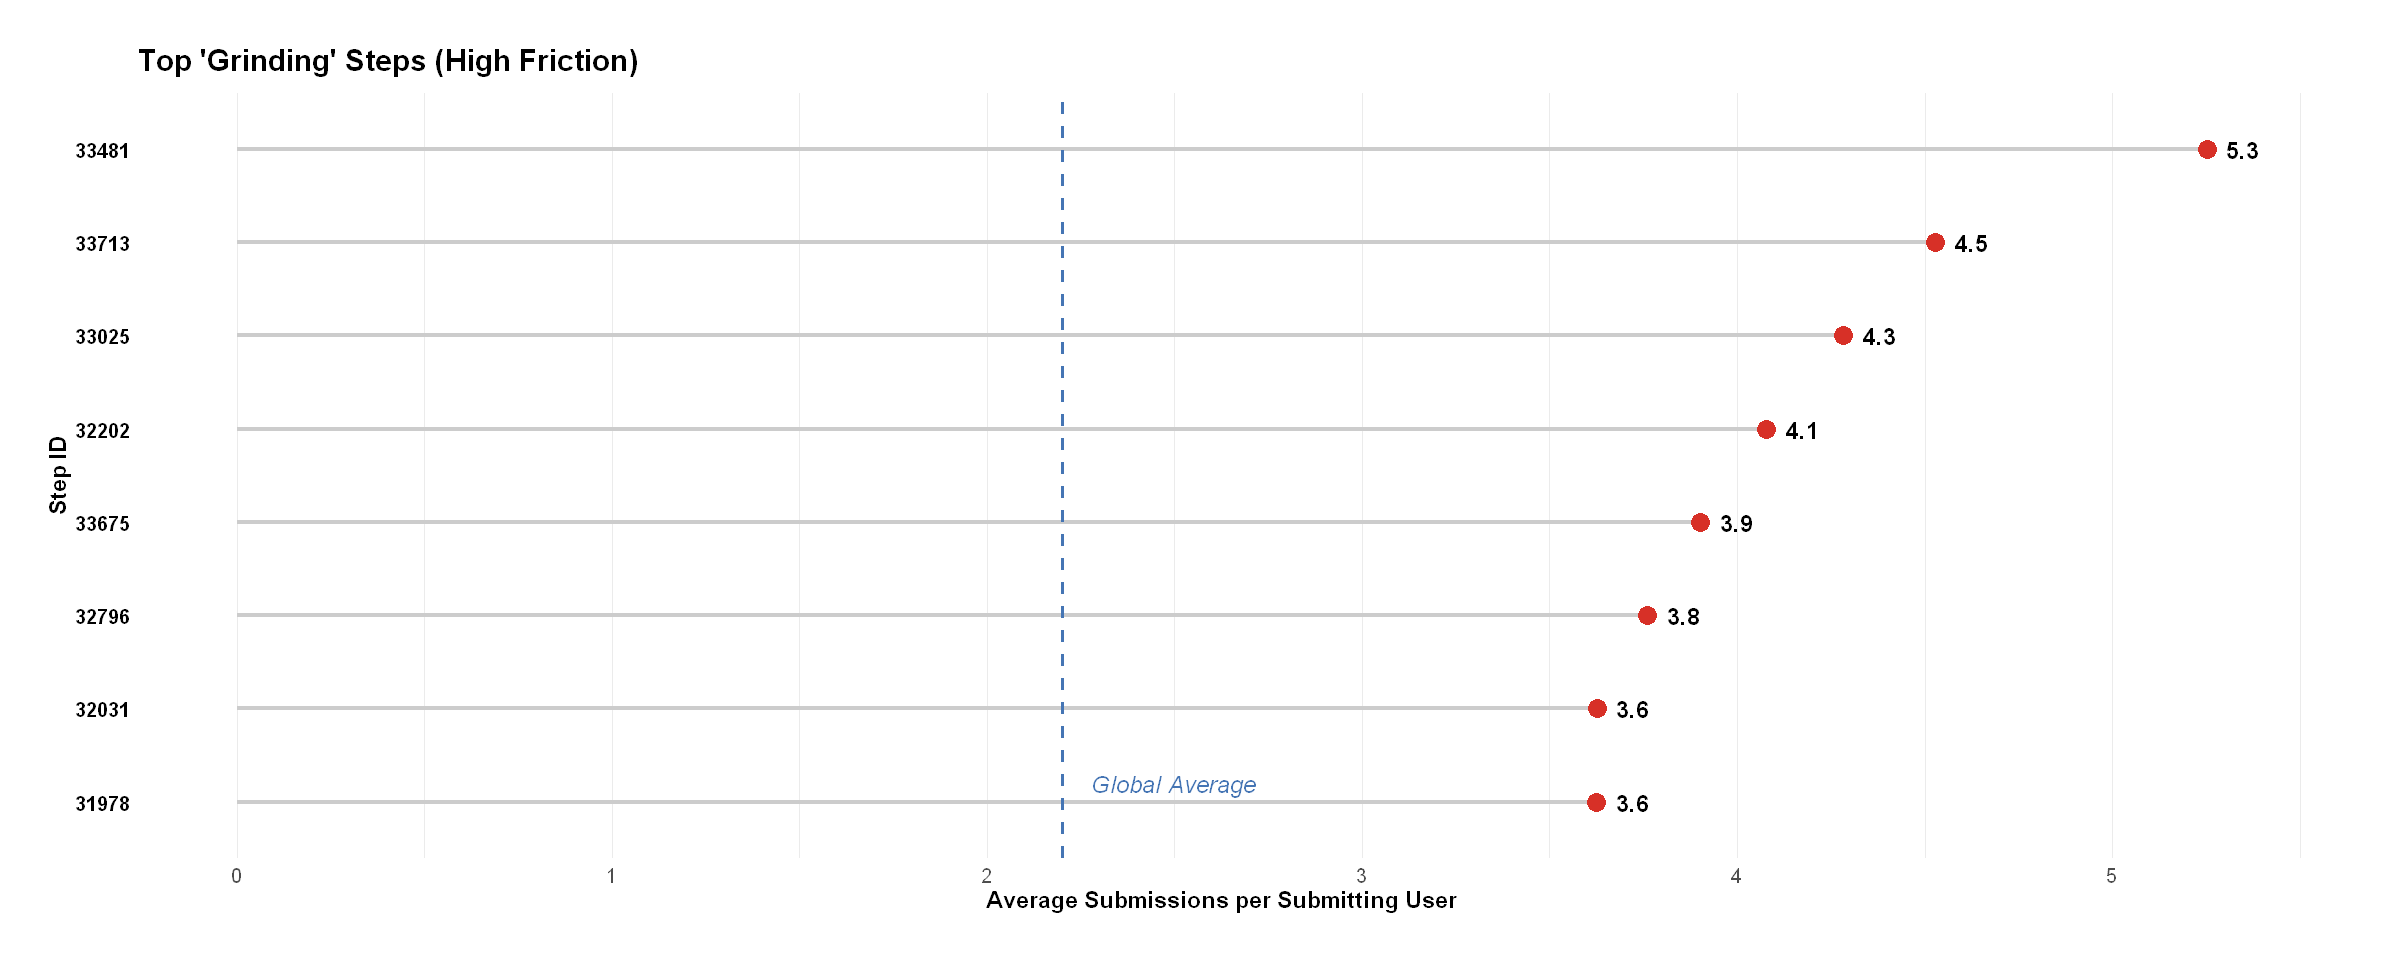

In [105]:
# Calculate global average for assignments only
global_avg_submissions_per_user <- mean(step_metrics[is_assignment == TRUE]$avg_submissions_per_user, na.rm = TRUE)

# Visualize "Grinding" stages (Lollipop Chart)
ggplot(grinding_steps, aes(x = reorder(as.character(step_id), avg_submissions_per_user), y = avg_submissions_per_user)) +
  
  # Draw the "sticks" (linewidth replaces size for lines)
  geom_segment(aes(xend = reorder(as.character(step_id), avg_submissions_per_user), yend = 0), 
               color = "grey80", 
               linewidth = 1.2) +
  
  # Draw the "heads" (points still use size)
  geom_point(color = "#d73027", size = 5) + 
  
  # Large value labels to the right of the points
  geom_text(aes(label = round(avg_submissions_per_user, 1)), 
            hjust = -0.6, 
            size = 5, 
            fontface = "bold", 
            color = "black") +
  
  # Global Average Baseline (linewidth replaces size)
  geom_hline(yintercept = global_avg_submissions_per_user, 
             linetype = "dashed", 
             color = "#4575b4", 
             linewidth = 1) +
  
  # Annotation for the baseline
  annotate("text", x = 1.2, y = global_avg_submissions_per_user + 0.3, 
           label = "Global Average", 
           color = "#4575b4", 
           size = 5, 
           fontface = "italic") + 
  
  # Flip coordinates and ensure labels aren't cut off
  coord_flip(clip = "off") + 
  
  # Labels and Titles
  labs(
    title = "Top 'Grinding' Steps (High Friction)",
    x = "Step ID", 
    y = "Average Submissions per Submitting User"
  ) +
  
  # Theme configuration
  theme_minimal() +
  theme(
    plot.title = element_text(face = "bold", size = 18, margin = margin(b=10)),
    plot.subtitle = element_text(size = 14, margin = margin(b=20)),
    axis.title = element_text(size = 14, face = "bold"),
    axis.text.y = element_text(size = 12, face = "bold", color = "black"),
    axis.text.x = element_text(size = 12),
    panel.grid.major.y = element_blank(),
    plot.margin = margin(1, 2, 1, 1, "cm") 
  )

**Key Finding: High-Effort Assignment Friction**

Using the P99-filtered assignment-level metrics, this analysis identifies "grinding" — assignment steps with unusually high submission effort. The top 10% of assignments by `avg_submissions_per_user` (`P90`) isolate **8 high-friction steps**.

The assignment median is **1.94 submissions per submitting user**, while the strongest grinding step reaches **5.3**, or about **2.7x** the median effort. The most notable bottlenecks are Step **33481** (**5.3**) and Step **33713** (**4.5**), followed by Step **33025** (**4.3**) and Step **32202** (**4.1**).

These steps should be treated as targeted review candidates rather than evidence of systemic assignment difficulty.

---

### Cross-Validating Friction Metrics

> **Technical Note: Risk Signal Integration & Cross-Audit**
>
> The cross-audit is performed on step-level metrics derived from the **P99-filtered analytical sample**.
>
> This block combines several complementary risk signals to identify steps with overlapping warning patterns. The goal is not to prove content failure, but to prioritize steps for manual pedagogical, UX, or technical review.
>
> **Prioritization Methodology**
>
> The prioritization is based on four diagnostic signals:
>
> * **Effort Intensity / Grinding:** assignment steps with `avg_submissions_per_user` at or above the 90th percentile.
> * **Task Performance / Pass Rate:** assignment steps with `pass_rate` in the bottom quartile of the assignment distribution.
> * **Final Observed Step:** steps appearing among the most frequent final recorded user interaction points.
> * **Traffic Drop Anomaly:** steps with robust lower-bound deviations in `step_to_step_traffic_ratio`, indicating sharp aggregate viewer-flow drops.
>
> **Analytical Objective**
>
> The primary goal of this integration is **risk prioritization and noise reduction**. A single signal may reflect normal learning difficulty, non-linear navigation, curriculum structure, or random variation. However, steps with multiple overlapping signals are stronger candidates for targeted review because they combine evidence from effort, performance, exit behavior, and aggregate traffic flow.
>
> In this framework, steps are classified as **High Priority** when they trigger two or more applicable signals. These steps should be interpreted as prioritized audit candidates, not as definitive proof of structural course failure.

In [106]:
# Full audit universe: all course steps
cross_audit <- step_metrics[, .(step_id, course_order, is_assignment)]

In [107]:
# Add diagnostic flags
cross_audit[
  ,
  `:=`(
    flag_grinding = fifelse(
      is_assignment,
      step_id %in% grinding_steps$step_id,
      NA
    ),

    flag_low_completion = fifelse(
      is_assignment,
      step_id %in% low_completion_steps$step_id,
      NA
    ),

    flag_final_exit =
      step_id %in% top_last_steps$step_id,

    flag_traffic_drop =
      step_id %in% low_zscore_steps$step_id
  )
]

In [108]:
# Count triggered signals
cross_audit[
  ,
  audit_score := rowSums(
    .SD,
    na.rm = TRUE
  ),
  .SDcols = c(
    "flag_grinding",
    "flag_low_completion",
    "flag_final_exit",
    "flag_traffic_drop"
  )
]

In [109]:
# Assign review priority
cross_audit[
  ,
  priority_group := fcase(
    audit_score >= 2, "High Priority",
    audit_score == 1, "Medium Priority",
    default = "No Flag"
  )
]

In [110]:
# Summarize how many steps fall into each priority group
# and how many diagnostic signals they triggered.
cross_audit_score_summary <- cross_audit[
  ,
  .(Steps = .N),
  by = .(priority_group, audit_score)
][
  order(-audit_score, priority_group)
]

cross_audit_score_summary

priority_group,audit_score,Steps
<chr>,<dbl>,<int>
High Priority,2,8
Medium Priority,1,30
No Flag,0,160


**Risk Signal Integration: Multi-Signal Validation**

The cross-audit was conducted across all **198 course steps** using the P99-filtered analytical user sample. The `audit_score` counts how many diagnostic risk signals were triggered for each step.

Most steps received no flag: **160 steps** had an `audit_score` of **0**. Another **30 steps** triggered one signal and were assigned to **Medium Priority**.

The strongest review candidates are the **8 High Priority steps**, each triggering **two overlapping risk signals**. These steps should be prioritized for targeted pedagogical, UX, or technical review.

Overall, the results suggest that course friction is **localized rather than systemic**: most steps appear stable, while a limited subset concentrates the strongest warning signals.

### Product Team Handoff: Prioritized Step Review File

In [111]:
# Create a product-team review table containing only flagged course steps
product_review_steps <- merge(
  cross_audit[
    priority_group != "No Flag"
  ],
  step_metrics[
    ,
    .(
      step_id,
      step_score,
      n_viewed,
      n_started_assignment,
      n_passed_assignment,
      start_rate,
      pass_rate,
      step_to_step_traffic_ratio,
      avg_submissions_per_user,
      robust_z_score
    )
  ],
  by = "step_id",
  all.x = TRUE
)


In [112]:
# Define business-readable descriptions for each diagnostic signal
signal_labels <- c(
  flag_grinding = "High submission effort",
  flag_low_completion = "Low assignment completion",
  flag_final_exit = "Frequent final observed step",
  flag_traffic_drop = "Strong next-step traffic drop"
)

In [113]:
# Combine all triggered signals into one readable explanation
product_review_steps[
  ,
  Review_Reason := apply(
    .SD,
    1,
    function(flags) {
      active_flags <- !is.na(flags) & as.logical(flags)

      paste(
        unname(signal_labels[active_flags]),
        collapse = "; "
      )
    }
  ),
  .SDcols = names(signal_labels)
]

In [114]:
# Define suggested areas for manual product review
action_labels <- c(
  flag_grinding =
    "Review task complexity, instructions, and validation logic",

  flag_low_completion =
    "Review difficulty, feedback quality, and solution guidance",

  flag_final_exit =
    "Review the transition to the next step and possible exit reasons",

  flag_traffic_drop =
    "Review content continuity, navigation, and event tracking"
)


In [115]:
# Combine suggested review actions for each flagged step
product_review_steps[
  ,
  Suggested_Review := apply(
    .SD,
    1,
    function(flags) {
      active_flags <- !is.na(flags) & as.logical(flags)

      paste(
        unname(action_labels[active_flags]),
        collapse = "; "
      )
    }
  ),
  .SDcols = names(action_labels)
]

In [116]:
# Prepare readable reporting fields
product_review_steps[
  ,
  `:=`(
    Step_Type = fifelse(
      is_assignment,
      "Assignment",
      "Theory/Video"
    ),

    Start_Rate_Pct =
      round(start_rate * 100, 1),

    Pass_Rate_Pct =
      round(pass_rate * 100, 1),

    Next_Step_Traffic_Pct =
      round(step_to_step_traffic_ratio * 100, 1),

    Avg_Submissions_Per_User =
      round(avg_submissions_per_user, 2),

    Traffic_Robust_Z =
      round(robust_z_score, 2)
  )
]


In [117]:
# Select and rename columns for the product-team handoff
product_review_steps <- product_review_steps[
  ,
  .(
    Step_ID = step_id,
    Course_Order = course_order,
    Step_Type,
    Priority = priority_group,
    Signals_Triggered = audit_score,
    Review_Reason,
    Suggested_Review,

    Viewers = n_viewed,
    Assignment_Starters = n_started_assignment,
    Successful_Users = n_passed_assignment,

    Start_Rate_Pct,
    Pass_Rate_Pct,
    Next_Step_Traffic_Pct,
    Avg_Submissions_Per_User,
    Step_Score = step_score,
    Traffic_Robust_Z,

    Flag_High_Submission_Effort = flag_grinding,
    Flag_Low_Completion = flag_low_completion,
    Flag_Final_Exit = flag_final_exit,
    Flag_Traffic_Drop = flag_traffic_drop
  )
]

In [118]:
# Sort high-priority steps first, then by course order
product_review_steps[
  ,
  Priority_Order := fcase(
    Priority == "High Priority", 1L,
    Priority == "Medium Priority", 2L,
    default = 3L
  )
]

setorder(
  product_review_steps,
  Priority_Order,
  -Signals_Triggered,
  Course_Order
)

product_review_steps[
  ,
  Priority_Order := NULL
]

**Optional Product-Team Export**

The prioritized step-review table is retained in the `product_review_steps` object.  
No separate file is exported in the current project because the analysis is intended as a portfolio demonstration.

If a product-team handoff is required, the table can be exported using the following code:

```r
reports_dir <- file.path(project_root, "reports")

dir.create(
  reports_dir,
  recursive = TRUE,
  showWarnings = FALSE
)

fwrite(
  product_review_steps,
  file.path(reports_dir, "product_team_step_review.csv")
)
```

---

### Key Finding: Step-Level

Step-level findings are based on the **P99-filtered analytical sample** and should be interpreted as typical-user friction patterns rather than high-intensity usage behavior.

**1. Structural Anomaly Analysis: Robust MAD Score**  
- - **Flow Irregularities:** The ±3 MAD reference band reveals pronounced aggregate traffic drops of around **50–60%**, together with traffic spikes above the upper bound. Lower-bound drops are included in the cross-audit, while upper-bound spikes are retained as contextual evidence of non-linear navigation.
- **Interpretation:** These deviations may reflect direct access, revisits, bookmarks, skipped steps, re-entry into the course sequence, or curriculum changes over time. Therefore, traffic-ratio anomalies should be treated as review signals rather than direct evidence of content failure.

**2. Final Observed Steps & Early Friction**  
- **Observed Exit Concentration:** The most frequent final recorded step is **Step ID 32815** (**Step №1** in the reconstructed order), with approximately **1,300 users** in the P99-filtered analytical sample.  
- **Early Drop-Off:** Several of the most frequent final observed steps are concentrated in the early part of the course, especially within the first 10 reconstructed steps. In the top-10 final observed steps, exits are primarily associated with **theory/video content**, suggesting an early activation and onboarding issue rather than assignment-level failure.

**3. Friction & Difficulty Scaling**  
- **Disproportionate Risk:** 2-point tasks represent **13.2%** of practical assignments but account for **26.3%** of the low-pass assignment subset. Their probability of being flagged as low-pass is approximately **2.4×** higher than for 1-point tasks.  
- **Grinding Effect:** Higher-friction assignments require substantially more repeated submissions, with the strongest grinding step reaching up to **5.3 submissions per submitting user**. This indicates that repeated effort is concentrated on specific tasks rather than distributed evenly across the practical layer.

**4. Technical Validation**  
- Some assignments exhibit elevated submission effort, while a separate subset shows comparatively low pass rates. Overlapping diagnostic signals are incorporated into the cross-audit prioritization.

**5. Cross-Metric Prioritization**  
- **Risk Coverage:** **38 of 198 steps** triggered at least one risk signal across grinding, pass-rate, final-exit, and traffic-flow diagnostics.  
- **Audit Score:** **30 steps** scored `1` and were assigned to **Medium Priority**; **8 steps** scored `2` and were assigned to **High Priority**.  
- **Scope Reduction:** Only **8 of 198 steps** reached High Priority, indicating localized rather than systemic friction.

## Final Project Key Insights and Behavioral Analysis

**1. Pre-Submission Churn (48.3%)**

Nearly half of users never submit a solution, indicating that the largest observed loss occurs before the first submission event.

This early drop-off is concentrated in three behavioral segments:

- **28.4% — Theorists:** users who never start an attempt and never view an assignment
- **12.4% — Task Viewers:** users who view at least one assignment but do not start an attempt
- **7.6% — Unfinished Attempts:** users who start an attempt but never submit a solution

Among users who do reach the submission stage:

- **50.9%** of all users achieve at least one correct submission
- **0.8% — Strugglers:** users who submit but never achieve a correct submission

---

**2. User Activity Diagnostics**

User activity is strongly right-skewed: a small group of P99-defined high-activity users inflates average-based metrics.

Median values provide a more stable view of typical engagement. In both the full and P99-filtered samples, the median user records:

* **8 passed events** across all steps
* **2 practical-start events**
* **1 practical pass event**

This shows that P99-filtering mainly reduces the extreme upper tail, while the typical learner profile remains stable: low-intensity, relatively early-stage engagement.

---

**3. Initiation vs. Completion**

Once users move into active task-solving, successful outcomes are highly likely.

At the step level, based on the P99-filtered assignment metrics:

- Mean Start Rate: **91.4%**
- Mean Assignment Pass Rate: **90.6%**
- Median Start Rate: **92.6%**
- Median Assignment Pass Rate: **91.3%**

These two metrics use different denominators and should be interpreted as separate funnel indicators: Start Rate captures conversion from assignment view to attempt, while Assignment Pass Rate captures conversion from attempt to correct submission.

At the user level:

- **98.5%** of users who submit at least once are observed to achieve at least one correct submission

This indicates that the main barrier is concentrated at the transition from passive exposure to first meaningful practical action.

---

**4. Structural & Content Friction (Step-Level)**

These findings are based on step-level metrics computed using the P99-filtered analytical user sample, with extreme high-activity users excluded.

Step-level analysis shows that friction is localized rather than systemic.

Key findings:

- Final observed steps are concentrated early in the course, especially before sustained practical engagement
- - Step-to-step traffic spikes above the robust upper reference bound provide contextual evidence of non-linear navigation, such as skipping, revisiting, direct access, or curriculum changes; they are not included as standalone risk signals in the prioritized cross-audit
- Only **8 of 198 steps** were classified as **High Priority** in the full-course cross-metric audit
- Among practical assignments, **2-point tasks are approximately 2.4× more likely** to be flagged as low-pass than 1-point tasks
- The most effort-intensive assignment steps require up to **5.3 submissions per submitting user**, which is approximately **2.7×** the assignment median

Overall, the course structure appears broadly stable, but several specific steps function as localized bottlenecks.

---

**5. Robustness Checks**

The main findings remain stable after controlling for P99-defined high-activity users.

Additional checks show that:

- minor logging inconsistencies are present, such as isolated activity patterns with missing preceding view or discovery events
- these anomalies are rare and do not alter the overall behavioral picture
- P99-filtering reduces upper-tail distortion but does not change the core activation pattern

This supports the conclusion that the observed patterns are structural rather than artifacts of data noise or extreme cases.

---

>**Final Conclusion**
>
>The main product challenge lies in early activation and the transition into practical engagement, not in broad assignment difficulty.
>
>In the full user funnel, most losses occur before practical engagement becomes established. In the P99-filtered step-level analysis, final observed steps and friction signals are concentrated mainly in the early course experience, while later-stage task difficulty affects a smaller subset of already engaged users.
>
>The highest-value improvement opportunities therefore lie in:
>
>- reducing the **theory-to-practice gap**
>- lowering the **barrier to first attempt**
>- reducing **friction between first attempt and first submission**

**Connection to the Next Project Stages**

These findings motivate the next two stages of the analytical workflow.

[**Part 2: Behavioral Segmentation and Completion Outcome Analysis**](02_behavioral_segmentation.ipynb) uses the resolved `model_base` sample prepared in this analysis to identify behaviorally distinct learner segments. The segmentation phase examines whether users with different engagement patterns — such as passive, steady, or burst-like behavior — also differ in their completion outcomes.

[**Part 3: Early Completion Risk Modeling**](03_completion_risk_modeling.ipynb) uses the exported `prediction_features_10d_model_base` to build supervised completion-risk models. The goal is to estimate each user's probability of eventual course completion and convert this output into a non-completion risk-ranking score for proactive retention prioritization.


---

## Actionable Recommendations

**1. Solving the Entry Barrier to Practical Engagement (Priority: High)**

* **Theoretical Content Audit**: Test shorter content units and lightweight micro-interactions in the early course section.
* **Lower the Entry Threshold**: Implement "skeleton code" for initial assignments to reduce perceived difficulty and encourage the first "Submit" action.

**2. Predictive Analytics & ML Strategy (Priority: Medium)**

* **Behavioral User Segmentation (Clustering)**: Use unsupervised learning to identify behavioral archetypes and tailor the curriculum to different learning speeds.
* **Course Completion Forecasting and Early-Risk Detection:** Develop a model to estimate completion probability and identify users at high risk of disengagement.

**3. Technical Monitoring (Priority: Low)**

* **Event-Logging Audit:** Review rare logging inconsistencies, including missing view/discovery events and correct submissions without matching passed events.
* **MAD-Based Monitoring:** Align historical data with the current curriculum structure to enable precise Robust Reference Band quality monitoring, ensuring that structural updates do not distort the performance baseline.
---

## Performance Enrichment: Integrating Success Metrics

> **Methodological Note: Performance Synthesis & Data Stabilization**
>
> This section defines the transition from raw activity logs to academic achievement metrics. The objective is to map reconstructed assignment scores to user accomplishments, establish the ground truth for course completion, and prepare a stable dataset for downstream modeling.
>
> * **Academic Scoring & Feature Engineering**  
>   Submission logs are transformed into performance indicators. Practical assignments are mapped to their reconstructed score weights to calculate each user’s `total_score`. Additional productivity metrics, such as score earned per active day, are derived to normalize achievement against learning intensity. This step also defines the binary target variable `certificate`, based on the completion threshold of **75 points**.

In [119]:
# Structural scoring lookup: assignment weights (step_score) are independent of P99 user filtering.
# Scores are calculated for all users; filtering is applied later only for modeling (model_base).
step_weights <- step_metrics[is_assignment == TRUE, .(step_id, step_score)]

In [120]:
# Filter for unique successful submissions to avoid double-counting re-submissions
unique_solutions <- unique(submissions_data[submission_status == 'correct', .(user_id, step_id)])

In [121]:
# Calculate total points earned by each user by merging solutions with step weights
user_scores <- merge(
  unique_solutions, 
  step_weights, 
  by = "step_id"
)[, .(total_score = sum(step_score)), by = user_id]

In [122]:
# Add total_score to users data frame
user_metrics[user_scores, on = .(user_id), total_score := i.total_score]

In [123]:
# Handle users with no correct submissions by replacing NA with zero
user_metrics[is.na(total_score), total_score := 0]

In [124]:
# Derive final performance-based features for ML analysis
user_metrics[, `:=`(
  # Productivity: reflects the average points earned per active day
  score_per_active_day    = total_score / active_days,
    
  # Course progress: percentage of the total possible 88 points 
  progress_percent_score = (total_score / 88) * 100,
    
  # Target Variable: binary flag for course completion (Threshold: 75 points)
  certificate      = as.integer(total_score >= 75)
)]

---

## Feature Engineering for ML

### Adding the `is_in_progress` Flag to user_metrics

In [125]:
# Calculate inactivity gaps (days) between consecutive active days.
# The first activity per user has no previous observation and therefore has gap_days = NA.
gap_distribution <- activity_days[
  order(user_id, day)
][
  , gap_days := as.numeric(day - shift(day)),
  by = user_id
]

# Add completion status
gap_distribution <- merge(
  gap_distribution,
  user_metrics[, .(user_id, certificate)],
  by = "user_id"
)

# Restrict the analysis to learners who eventually completed the course
completed_gaps <- gap_distribution[
  certificate == 1 &
    !is.na(gap_days)
]


In [126]:
# Print section header
cat("\n========================================================\n")
cat(" Inactivity Gap Distribution (Course Completers)\n")
cat("========================================================\n\n")

# Print summary statistics
cat("Summary Statistics:\n")
print(summary(completed_gaps$gap_days))

# Print selected inactivity-gap percentiles
cat("\nSelected Percentiles:\n")
print(
  quantile(
    completed_gaps$gap_days,
    probs = c(
      0.50,
      0.75,
      0.90,
      0.95,
      0.97,
      0.98,
      0.99
    )
  )
)


 Inactivity Gap Distribution (Course Completers)

Summary Statistics:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    1.0     1.0     1.0    11.8     3.0  1017.0 

Selected Percentiles:
  50%   75%   90%   95%   97%   98%   99% 
  1.0   3.0  14.0  44.0  91.0 142.1 249.1 


**Observation: Inactivity Gap Distribution**

Since the objective is to identify inactivity periods that remain compatible with successful course completion, the analysis is restricted to learners who eventually completed the course. The inactivity gap distribution is highly right-skewed: most observed gaps are short (**median = 1 day; 75% ≤ 3 days)**, while occasional substantially longer interruptions produce a pronounced right tail. This indicates that although successful learners typically study continuously, some are able to resume learning even after extended periods of inactivity.

In [127]:
# Coverage of observed inactivity gaps among course completers
thresholds <- c(7, 10, 14, 21, 30)

gap_coverage <- data.table(
  threshold = thresholds,
  coverage = sapply(
    thresholds,
    function(x)
      mean(completed_gaps$gap_days <= x)
  )
)

gap_coverage

threshold,coverage
<dbl>,<dbl>
7,0.8585822
10,0.8829667
14,0.9032970
21,0.9233590
30,0.9371311


**Threshold Selection**

A 14-day threshold covers approximately **90.3%** of all observed inactivity gaps among course completers. Extending the threshold to 21 or 30 days increases the coverage only marginally (**92.3%** and **93.7%**, respectively). Therefore, a **14-day inactivity threshold was selected** as the operational rule for identifying learners who may still be progressing through the course.

In [128]:
# Fixed business threshold for unresolved learning trajectories
business_threshold <- 14

In [129]:
# Determine the latest timestamp in the dataset to represent "today" (Snapshot Date)
max_snapshot <- max(as_date(user_metrics$last_timestamp), na.rm = TRUE)

In [130]:
# A user is considered still in progress if:
# - they have not earned a certificate, and
# - their last recorded activity falls within the last 14 days of the snapshot
user_metrics[, is_in_progress := as.integer(
  certificate == 0 &
  (max_snapshot - as_date(last_timestamp) <= business_threshold)
)]

---

## Dataset Construction for ML

>**Technical Note: Preparation of the Modeling Dataset**
>
>To ensure that clustering and predictive models were trained on complete and comparable learning trajectories, the modeling dataset was restricted as follows:
>
> - Users above the 99th percentile of cumulative activity were excluded to reduce the influence of extreme behavioral outliers.
> - Users whose status remained `is_in_progress` at the time of the dataset snapshot were excluded because their learning trajectories were still incomplete.
>
>Excluding these users prevents partially observed behavior from biasing cumulative engagement features and allows both clustering and supervised models (Random Forest and XGBoost) to be trained on trajectories classified as operationally resolved at the dataset snapshot using the 14-day inactivity rule.
>
>The complete dataset was retained for descriptive analyses, inactivity-threshold analysis, and inspection of edge cases.

In [131]:
# Recreate P99-filtered user-level dataset after all performance
# and status features are added.
user_metrics_no_extreme <- user_metrics[
  is_extreme == FALSE
]

In [132]:
# Final analytical sample for clustering and supervised modeling
# Users still classified as is_in_progress are excluded unless they already earned a certificate.
model_base <- user_metrics_no_extreme[
  certificate == 1 | is_in_progress == 0
]

model_user_ids <- model_base$user_id

---

### Preparing Data for Clustering ML

>**Methodological Note:**
>
>Clustering is based on a mixed user-profile feature space. 
The selected variables primarily describe behavioral rhythms and engagement intensity, 
but also include limited performance-related signals (for example, `submission_correct_rate` and `score_per_active_day`) 
to capture differences in learning effectiveness alongside interaction patterns.

In [133]:
# List of features names for clustering
# `user_id` is retained only as a technical identifier for joining clustering results back to the user-level dataset. 
# It is excluded from the feature matrix before scaling and model training.
features_clustering_base <- c(
  "user_id",
  "active_days", 
  "median_gap_days", 
  "submission_correct_rate", 
  "view_frequency", 
  "submission_frequency", 
  "steps_per_active_day", 
  "score_per_active_day"
)

In [134]:
# Subset the analytical base to retain only the selected clustering variables.
cluster_features_model_base <- model_base[, ..features_clustering_base]

---

### Preparing Data for Prediction ML

#### Determining the Observation Window

> **Methodological Note: Observation Window Selection**
>
>Before constructing the modeling dataset, an appropriate observation window must be defined. Rather than selecting this period a priori, cumulative learner activity was examined as a function of time since each learner's first recorded course activity. The first 30 calendar days were used only as an exploratory analysis horizon to assess how much of the early learning trajectory contains useful behavioral information for subsequent feature generation.

In [135]:
# Base cohort for window analysis
users_base <- last_ts[
  user_id %in% model_user_ids,
  .(user_id, first_timestamp)]

In [136]:
# Merge P99-filtered event logs with each user's first observed activity date
# to calculate the day index relative to course entry.
events_full <- merge(
  events_data_no_extreme[user_id %in% model_user_ids],
  users_base,
  by = "user_id",
  all.x = FALSE,
  all.y = FALSE
)

In [137]:
# Create a 1-based day index:
# Day 1 = the user's first observed activity date.
events_full[, day_index := as.integer(
  as_date(timestamp_dt) - as_date(first_timestamp)
) + 1]

# Keep only events recorded within the first 30 calendar days
# from each user's first observed activity.
events_full <- events_full[
  day_index >= 1 & day_index <= 30
]

# Daily event increments by user and calendar day
daily_events <- events_full[, .(
  inc_viewed = sum(action == "viewed"),
  inc_passed_all = sum(action == "passed"),
  inc_started_practical = sum(action == "started_attempt"),
  inc_passed_practical = sum(
    action == "passed" & is_assignment == TRUE
  )
), by = .(user_id, day_index)]

In [138]:
# Create a complete user-day grid for the first 30 calendar days
# so that days without recorded activity are retained explicitly.
full_grid <- CJ(
  user_id = users_base$user_id,
  day_index = 1:30,
  unique = TRUE
)

In [139]:
# Merge the complete grid with observed daily activity counts.
panel_dt <- merge(
  full_grid,
  daily_events,
  by = c("user_id", "day_index"),
  all.x = TRUE
)

In [140]:
# List of daily increment variables to complete.
inc_cols <- c(
  "inc_viewed",
  "inc_passed_all",
  "inc_started_practical",
  "inc_passed_practical"
)

In [141]:
# Replace missing daily counts with zero,
# meaning no recorded activity on that user-day.
for (col in inc_cols) {
  set(panel_dt, which(is.na(panel_dt[[col]])), col, 0L)
}

In [142]:
# Cumulative user trajectories 
setorder(panel_dt, user_id,  day_index)

panel_dt[, `:=`(
  cum_viewed            = cumsum(inc_viewed),
  cum_passed_all        = cumsum(inc_passed_all),
  cum_started_practical = cumsum(inc_started_practical),
  cum_passed_practical  = cumsum(inc_passed_practical)
), by = user_id]

In [143]:
# Cohort-level summary for window selection
daily_summary_full_panel <- panel_dt[, .(
  median_viewed            = as.numeric(median(cum_viewed)),
  p25_viewed               = as.numeric(quantile(cum_viewed, 0.25)),
  p75_viewed               = as.numeric(quantile(cum_viewed, 0.75)),

  median_passed_all        = as.numeric(median(cum_passed_all)),
  p25_passed_all           = as.numeric(quantile(cum_passed_all, 0.25)),
  p75_passed_all           = as.numeric(quantile(cum_passed_all, 0.75)),

  median_started_practical = as.numeric(median(cum_started_practical)),
  p25_started_practical    = as.numeric(quantile(cum_started_practical, 0.25)),
  p75_started_practical    = as.numeric(quantile(cum_started_practical, 0.75)),

  median_passed_practical  = as.numeric(median(cum_passed_practical)),
  p25_passed_practical     = as.numeric(quantile(cum_passed_practical, 0.25)),
  p75_passed_practical     = as.numeric(quantile(cum_passed_practical, 0.75))
), by =  day_index][order(day_index)]


# Table
daily_summary_full_panel

day_index,median_viewed,p25_viewed,p75_viewed,median_passed_all,p25_passed_all,p75_passed_all,median_started_practical,p25_started_practical,p75_started_practical,median_passed_practical,p25_passed_practical,p75_passed_practical
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,5,1,16,4,1,11,1,0,3,0,0,2
2,6,1,20,4,1,12,1,0,4,0,0,2
3,6,1,23,4,1,14,1,0,4,0,0,2
4,7,1,25,4,1,16,1,0,5,0,0,2
5,7,1,27,5,1,16,1,0,5,0,0,3
6,7,1,29,5,1,17,1,0,6,0,0,3
7,8,1,30,5,1,19,1,0,6,0,0,4
8,8,1,32,5,1,20,1,0,7,0,0,4
9,8,1,33,5,1,20,1,0,7,0,0,4


In [144]:
# Prepare a compact plotting table for cumulative view-event trajectories:
# median line with interquartile range (P25-P75) by day index.
viewed_band <- daily_summary_full_panel[, .(
  day_index,
  median = median_viewed,
  p25 = p25_viewed,
  p75 = p75_viewed
)]

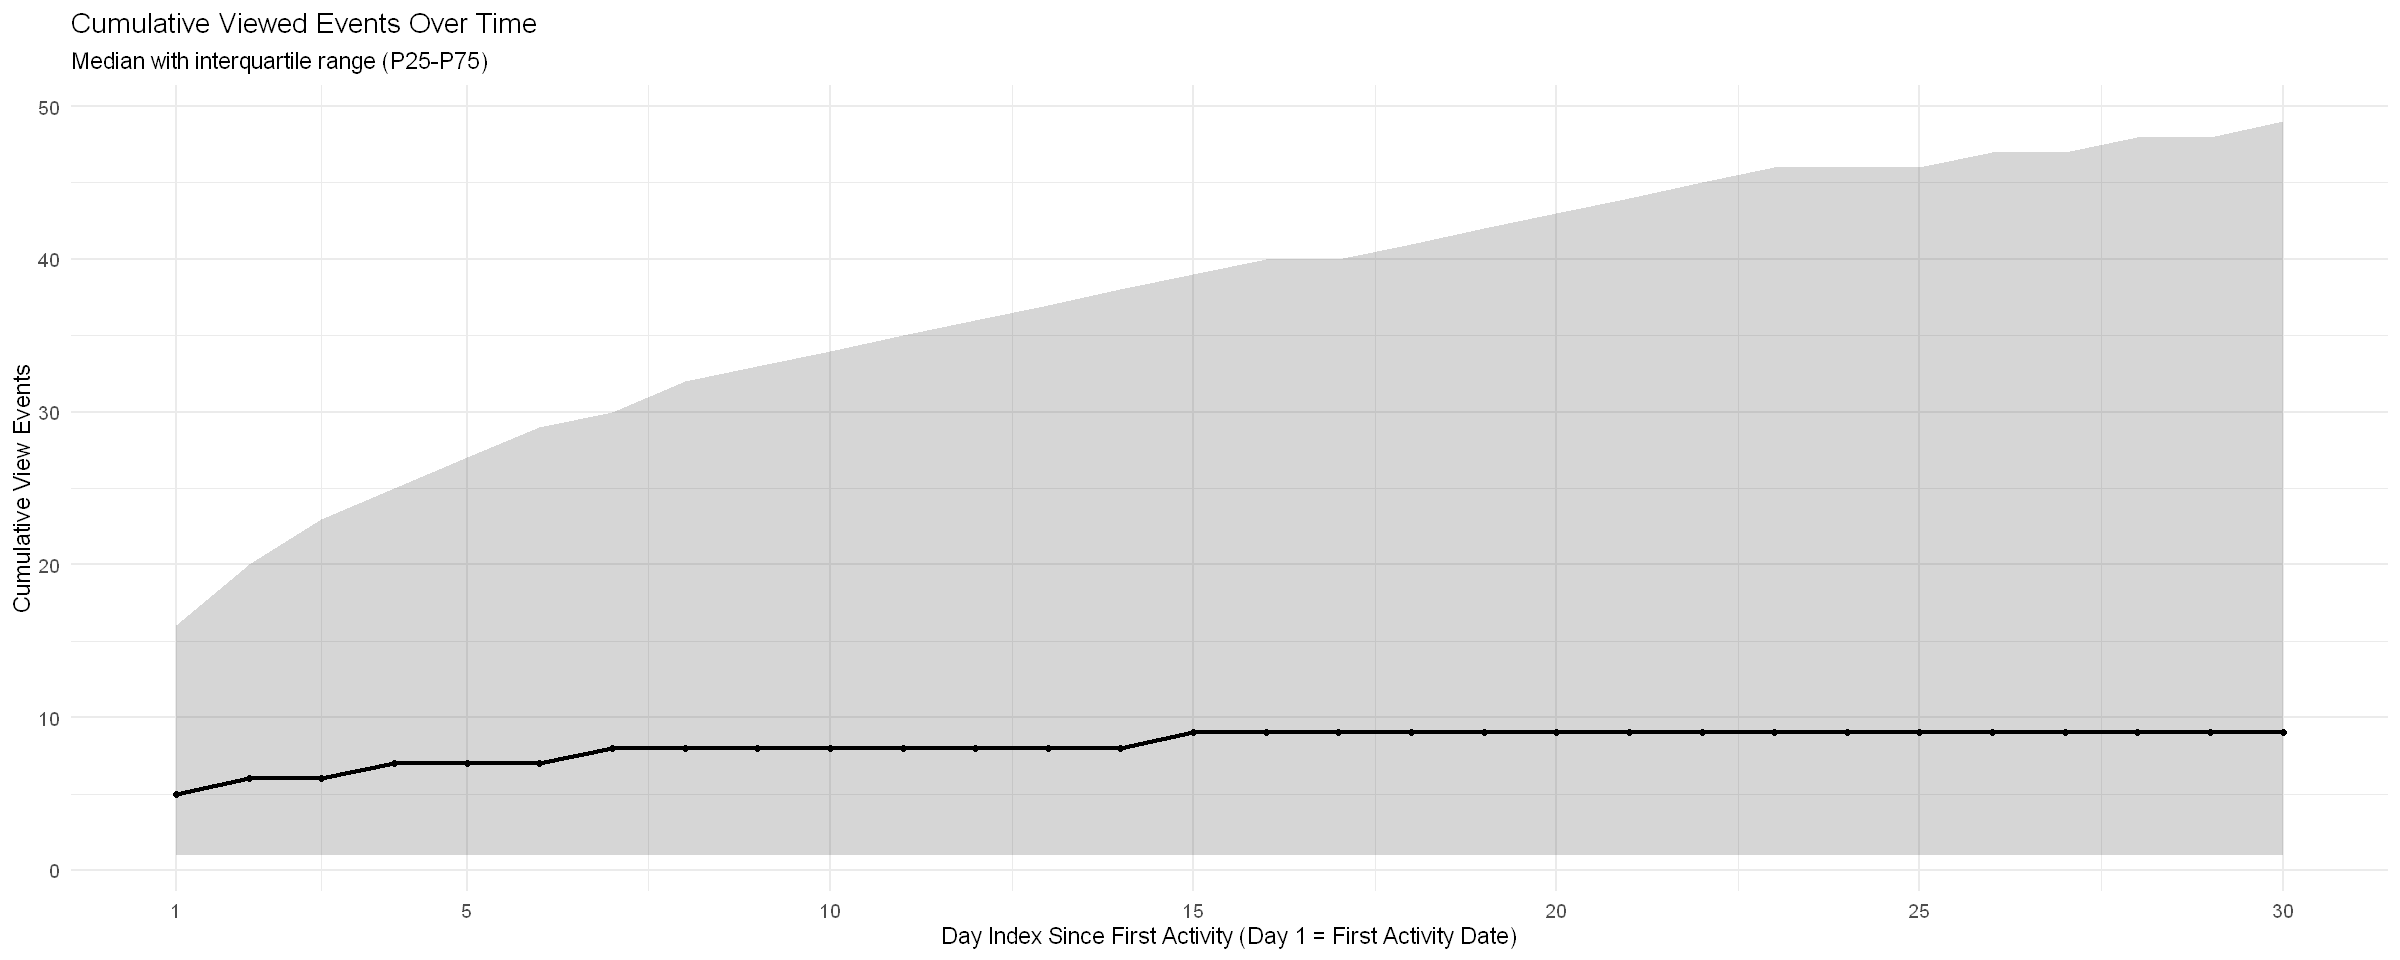

In [145]:
# Plot the cumulative view-event trajectory over the first 30 days
# The line shows the cohort median, and the ribbon shows the interquartile range.
ggplot(viewed_band, aes(x = day_index, y = median)) +
  geom_ribbon(aes(ymin = p25, ymax = p75), alpha = 0.2) +
  geom_line(linewidth = 1.2) +
  geom_point(size = 1.5) +
  scale_x_continuous(breaks = c(1, 5, 10, 15, 20, 25, 30)) +
  labs(
    title = "Cumulative Viewed Events Over Time",
    subtitle = "Median with interquartile range (P25-P75)",
    x = "Day Index Since First Activity (Day 1 = First Activity Date)",
    y = "Cumulative View Events"
  ) +
  theme_minimal(base_size = 14)

**Observation Window Selection**

The selected 10-day window should be interpreted as a modeling-oriented benchmark derived from the analytical modeling sample, rather than from the full raw user population.

As shown in the cumulative trajectory plot above, the main behavioral signal for the typical learner is captured early in the user journey. During the first **10 calendar days of activity (`day_index` 1–10)**, the median number of viewed steps increases quickly and then changes only marginally afterward.

Additional observation beyond day 10 mainly captures continued activity among more engaged users, as reflected by the widening upper quartile. However, it adds limited additional information for the median learner profile.

This makes **10 days** a reasonable operational baseline: it captures the early engagement signal while keeping the prediction point sufficiently early for practical intervention.

A shorter **7-day** window may also be plausible and can be treated as a robustness check in future iterations. In the current pipeline, the **10-day window** is retained as the primary observation window.

#### Feature Engineering (10-Day Observation Window)

In [146]:
# Define a 10-calendar-day observation window:
user_deadline <- users_base[, .(
  user_id,
  deadline_date = as_date(first_timestamp) + days(9)
)]

In [147]:
# Filter events and submissions to the 10-day window
filtered_events <- events_data_no_extreme[
  user_id %in% model_user_ids
][user_deadline, on = "user_id"][
  as_date(timestamp_dt) <= deadline_date
]

filtered_submissions <- submissions_data_no_extreme[
  user_id %in% model_user_ids
][user_deadline, on = "user_id"][
  as_date(timestamp_dt) <= deadline_date
]

In [148]:
# Event-based activity and progress counts
X_train <- filtered_events[, .(
  n_passed_all = sum(action == "passed"),
  n_viewed_all = sum(action == "viewed"),
  n_started_practical = sum(action == "started_attempt"),
  n_passed_practical = sum(
    action == "passed" & is_assignment == TRUE
  )
), by = user_id]

In [149]:
# All activity sources
all_activities <- rbind(
  filtered_events[, .(user_id, timestamp_dt)],
  filtered_submissions[, .(user_id, timestamp_dt)]
)

In [150]:
# Active days
active_days_dt <- all_activities[, .(
  active_days = uniqueN(as.Date(timestamp_dt))
), by = user_id]

In [151]:
# Derive score-based features within the 10-day observation window.

# Keep unique user-step pairs with at least one correct submission
# so that each practical step contributes points at most once per user.
user_correct_steps <- unique(
  filtered_submissions[submission_status == "correct", .(user_id, step_id)]
)

# Attach the reconstructed step score to each correctly solved practical step.
user_scores_10d <- merge(
  user_correct_steps,
  step_weights,
  by = "step_id",
  all.x = TRUE
)

# Sum earned points across correctly solved practical steps for each user.
user_score_totals <- user_scores_10d[, .(
  total_score = sum(step_score, na.rm = TRUE)
), by = user_id]

# Add active-day counts in order to normalize score accumulation by time on platform.
user_score_totals <- merge(
  user_score_totals,
  active_days_dt,
  by = "user_id",
  all.x = TRUE
)

# Compute score productivity as points earned per active day
# within the 10-day observation window.
user_score_totals[, score_per_active_day := ifelse(
  active_days > 0,
  total_score / active_days,
  0
)]

In [152]:
# Diagnostic: users already reaching the completion threshold
# within the 10-day observation window

early_completion_threshold_check <- user_score_totals[, .(
  users_reaching_75_within_10d = sum(total_score >= 75, na.rm = TRUE),
  share_reaching_75_within_10d = round(
    sum(total_score >= 75, na.rm = TRUE) / length(unique(model_user_ids)),
    4
  ),
  max_10d_score = max(total_score, na.rm = TRUE)
)]

early_completion_threshold_check

users_reaching_75_within_10d,share_reaching_75_within_10d,max_10d_score
<int>,<dbl>,<int>
126,0.0069,88


>**Technical Note: Early Completion Threshold Check**
>
>A small group of users already reached the 75-point completion threshold within the first 10-day observation window. This affects 126 users, or about 0.69% of the modeling population.
>
>This is expected because completion is score-based and some learners progress very quickly. The check confirms that progress- and score-related variables should be interpreted as early progress-monitoring signals rather than fully leakage-free predictors of future completion.

In [153]:
# Recency feature:
# for each user, identify the last recorded activity timestamp
# within the 10-day observation window.
recency_table <- all_activities[, .(
  last_timestamp = max(timestamp_dt)
), by = user_id]

# Attach each user's observation-window end date.
recency_table <- merge(
  recency_table,
  user_deadline[, .(user_id, deadline_date)],
  by = "user_id",
  all.x = TRUE
)

# Calculate how many calendar days passed between
# the user's last recorded activity and the end of the 10-day window.
recency_table[, days_since_last_action := as.integer(
  deadline_date - as_date(last_timestamp)
)]

In [154]:
# Submission features
X_subs <- filtered_submissions[, .(
  n_submissions = .N,
  submission_correct_rate = mean(submission_status == "correct", na.rm = TRUE)
), by = user_id]

In [155]:
# Build the final user-level feature table for the 10-day observation window.

# Start from the full set of users in the modeling cohort
# so that users with zero activity in specific feature blocks are retained.
base_users <- user_deadline[, .(user_id)]

# Sequentially merge all feature blocks into one user-level table.
prediction_features_10d_model_base <- merge(
  base_users, X_train, by = "user_id", all.x = TRUE
)
prediction_features_10d_model_base <- merge(
  prediction_features_10d_model_base,
  X_subs,
  by = "user_id",
  all.x = TRUE
)
prediction_features_10d_model_base <- merge(
  prediction_features_10d_model_base,
  active_days_dt,
  by = "user_id",
  all.x = TRUE
)
prediction_features_10d_model_base <- merge(
  prediction_features_10d_model_base,
  recency_table[, .(user_id, days_since_last_action)],
  by = "user_id",
  all.x = TRUE
)
prediction_features_10d_model_base <- merge(
  prediction_features_10d_model_base,
  user_score_totals[, .(user_id, score_per_active_day)],
  by = "user_id",
  all.x = TRUE
)

In [156]:
# Derive passed-event intensity per active day within the 10-day window.
prediction_features_10d_model_base[, steps_per_active_day := ifelse(
  active_days > 0,
  n_passed_all / active_days,
  0
)]

In [157]:
# Replace missing values with zero.
# Missing values here mean that the user had no recorded activity
# for the corresponding feature block within the 10-day window.
for (j in seq_len(ncol(prediction_features_10d_model_base))) {
  set(
    prediction_features_10d_model_base,
    which(is.na(prediction_features_10d_model_base[[j]])),
    j,
    0
  )
}

### Feature Engineering: Modeling Targets

In [158]:
# Final completion target
completion_target_model_base <- model_base[, .(
  user_id,
  completion_status = factor(
    ifelse(certificate == 1, "Completed", "Not_Completed"),
    levels = c("Not_Completed", "Completed")
  )
)]

## Data Export: Preparing for ML (Clustering & Prediction)

## Final Dataset Summary

This section summarizes the final analytical datasets created during the analysis. The datasets serve different purposes across exploratory analysis, clustering, supervised modeling, and data-quality validation. They are linked by `user_id` where applicable.

| Dataset                              | Purpose                                                           | Unit of Analysis | User Filtering                                                                                               | Time Window                                          | Target Included                     | Used In                                     |
| :----------------------------------- | :---------------------------------------------------------------- | :--------------- | :----------------------------------------------------------------------------------------------------------- | :--------------------------------------------------- | :---------------------------------- | :------------------------------------------ |
| `user_metrics`                       | Master user-level table for feature engineering and audit         | 1 row = 1 user   | All users                                                                                                    | Full observed history                                | `certificate`, `is_in_progress`     | EDA, audit, dataset construction            |
| `model_base`                         | Unified analytical sample for downstream ML                       | 1 row = 1 user   | Excludes P99-defined high-activity users and unresolved non-completed users still marked as `is_in_progress` | Full observed history                                | `certificate`                       | Base for clustering and prediction datasets |
| `cluster_features_model_base`        | User-level behavioral features prepared for clustering            | 1 row = 1 user   | `model_base` only                                                                                            | Full observed history                                | No                                  | K-means clustering                          |
| `prediction_features_10d_model_base` | Early behavioral features prepared for supervised modeling        | 1 row = 1 user   | `model_base` only                                                                                            | First 10 calendar days since first recorded activity | No                                  | Completion prediction                       |
| `completion_target_model_base`       | Final completion target stored separately from the feature tables | 1 row = 1 user   | `model_base` only                                                                                            | Snapshot outcome                                     | Yes (`Completed` / `Not_Completed`) | Supervised modeling                         |

Only the datasets required by the downstream modeling notebooks are exported:

* `cluster_features_model_base.csv`
* `prediction_features_10d_model_base.csv`
* `completion_target_model_base.csv`

The remaining analytical tables are retained as intermediate objects within this notebook and can be regenerated by rerunning the analysis.


In [159]:
# Final integrity checks before exporting downstream datasets

cluster_feature_cols <- setdiff(
  names(cluster_features_model_base),
  "user_id"
)

prediction_feature_cols <- setdiff(
  names(prediction_features_10d_model_base),
  "user_id"
)

stopifnot(
  # One row per user
  uniqueN(model_base$user_id) == nrow(model_base),

  uniqueN(cluster_features_model_base$user_id) ==
    nrow(cluster_features_model_base),

  uniqueN(prediction_features_10d_model_base$user_id) ==
    nrow(prediction_features_10d_model_base),

  uniqueN(completion_target_model_base$user_id) ==
    nrow(completion_target_model_base),

  # Same analytical population
  nrow(cluster_features_model_base) == nrow(model_base),
  nrow(prediction_features_10d_model_base) == nrow(model_base),
  nrow(completion_target_model_base) == nrow(model_base),

  setequal(
    cluster_features_model_base$user_id,
    model_base$user_id
  ),

  setequal(
    prediction_features_10d_model_base$user_id,
    model_base$user_id
  ),

  setequal(
    completion_target_model_base$user_id,
    model_base$user_id
  ),

  # Valid feature values
  !anyNA(cluster_features_model_base),
  !anyNA(prediction_features_10d_model_base),

  all(
    is.finite(
      as.matrix(
        cluster_features_model_base[
          ,
          ..cluster_feature_cols
        ]
      )
    )
  ),

  all(
    is.finite(
      as.matrix(
        prediction_features_10d_model_base[
          ,
          ..prediction_feature_cols
        ]
      )
    )
  ),

  # Valid target
  !anyNA(completion_target_model_base$completion_status),

  identical(
    levels(completion_target_model_base$completion_status),
    c("Not_Completed", "Completed")
  )
)

In [160]:
# Define output file paths for the final downstream datasets.
output_path_cluster_features <- file.path(
  processed_data_dir,
  "cluster_features_model_base.csv"
)

output_path_completion_target <- file.path(
  processed_data_dir,
  "completion_target_model_base.csv"
)

output_path_prediction_features <- file.path(
  processed_data_dir,
  "prediction_features_10d_model_base.csv"
)

# Export the final feature and target datasets.
fwrite(
  cluster_features_model_base,
  output_path_cluster_features
)

fwrite(
  completion_target_model_base,
  output_path_completion_target
)

fwrite(
  prediction_features_10d_model_base,
  output_path_prediction_features
)


In [161]:
# Print a compact export summary using project-relative paths
cat("\n--- Export Summary ---\n")

cat(
  "Clustering features:        ",
  file.path(
    "data",
    "processed",
    basename(output_path_cluster_features)
  ),
  "\n"
)

cat(
  "Completion target:          ",
  file.path(
    "data",
    "processed",
    basename(output_path_completion_target)
  ),
  "\n"
)

cat(
  "Prediction 10-day features: ",
  file.path(
    "data",
    "processed",
    basename(output_path_prediction_features)
  ),
  "\n"
)

cat(
  "Final analytical sample:    ",
  nrow(completion_target_model_base),
  "users\n"
)


--- Export Summary ---
Clustering features:         data/processed/cluster_features_model_base.csv 
Completion target:           data/processed/completion_target_model_base.csv 
Prediction 10-day features:  data/processed/prediction_features_10d_model_base.csv 
Final analytical sample:     18168 users
